# IMPORTAÇÃO

In [3]:
! pip install pandas openpyxl numpy nbformat plotly ipykernel
import pandas as pd
import numpy as np
import plotly.express as px
import nbformat
import ipykernel


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df: pd.DataFrame = pd.read_csv('dados_streaming.csv')

display(df)

,cliente_id,churn,idade,genero,regiao,tipo_contrato,metodo_pagamento,plano_assinatura,valor_mensal,tempo_assinatura_meses,dias_ultimo_acesso,acessibilidade,contatos_suporte,visualizacoes_mes,tempo_medio_sessao_min,dispositivo_principal,categoria_favorita,avaliacao_conteudo_media,avaliacao_conteudo_ultimo_mes,avaliacao_plataforma
0,1,0,22,NaN,Nordeste,Mensal,Pix,Básico,20.9,34,1,0,2,1,17.3,Tablet,Novelas,3.5,3.0,NaN
1,2,1,24,Feminino,Nordeste,Mensal,Débito Automático,Básico,20.9,30,5,0,5,0,35.6,Mobile,Documentários,4.0,4.5,3.5
2,3,1,27,Feminino,Sul,Mensal,Boleto,Básico,20.9,1,5,0,1,19,34.8,Tablet,Infantil,NaN,4.0,4.5
3,4,0,28,Masculino,Nordeste,Mensal,Crédito Recorrente,Padrão,44.9,3,11,0,1,48,40.7,Tablet,Infantil,NaN,2.5,NaN
4,5,0,25,Masculino,Sudeste,Mensal,Débito,Básico,20.9,29,1,0,3,43,32.1,Mobile,Séries,3.5,3.5,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31346,31347,1,39,Feminino,Nordeste,Mensal,Débito Automático,Padrão,44.9,9,17,0,0,25,22.8,TV,Novelas,NaN,1.0,4.0
31347,31348,0,27,Feminino,Sudeste,Anual,Crédito Recorrente,Premium,48.9,27,5,1,2,16,31.3,TV,Documentários,4.0,NaN,NaN
31348,31349,0,35,Masculino,Sudeste,Anual,Crédito Recorrente,Padrão,38.9,9,8,0,0,32,29.7,Desktop,Infantil,5.0,4.0,NaN
31349,31350,1,44,Prefiro Não Informar,Sudeste,Anual,Crédito Recorrente,Básico,18.9,29,4,1,4,49,33.9,Mobile,Novelas,2.5,NaN,4.0


In [5]:
tabela = df.copy()
tabela = tabela.drop(columns= "cliente_id")
display(tabela.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31351 entries, 0 to 31350
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   churn                          31351 non-null  int64  
 1   idade                          31351 non-null  int64  
 2   genero                         28008 non-null  object 
 3   regiao                         31351 non-null  object 
 4   tipo_contrato                  31351 non-null  object 
 5   metodo_pagamento               31351 non-null  object 
 6   plano_assinatura               31351 non-null  object 
 7   valor_mensal                   31351 non-null  float64
 8   tempo_assinatura_meses         31351 non-null  int64  
 9   dias_ultimo_acesso             31351 non-null  int64  
 10  acessibilidade                 31351 non-null  int64  
 11  contatos_suporte               31351 non-null  int64  
 12  visualizacoes_mes              31351 non-null 

None

In [6]:
# 1. Cria a coluna de controle de falta
df['falta_genero'] = df['genero'].isnull().astype(int)

# 2. TESTE 1: MCAR? (Relação com Churn)
print("=== TESTE 1: A falta de gênero está ligada ao CHURN? ===")
tab_churn = pd.crosstab(df['falta_genero'], df['churn'], normalize='index')
print(tab_churn)
print("\nSe os valores da linha 1 (NaN) forem MUITO diferentes da linha 0 (Preenchido) -> NÃO É MCAR.")

# 3. TESTE 2: MAR? (Relação com Acessibilidade - SUA PISTA)
print("\n=== TESTE 2: A falta de gênero está ligada à ACESSIBILIDADE? ===")
tab_acess = pd.crosstab(df['falta_genero'], df['acessibilidade'])
print(tab_acess)
print("\nOlhe para a coluna 0 (Sem Acessibilidade). Se a proporção de NaN for maior ali -> É MAR.")

=== TESTE 1: A falta de gênero está ligada ao CHURN? ===
churn                0         1
falta_genero                    
0             0.711190  0.288810
1             0.715525  0.284475

Se os valores da linha 1 (NaN) forem MUITO diferentes da linha 0 (Preenchido) -> NÃO É MCAR.

=== TESTE 2: A falta de gênero está ligada à ACESSIBILIDADE? ===
acessibilidade      0     1
falta_genero               
0               24932  3076
1                2973   370

Olhe para a coluna 0 (Sem Acessibilidade). Se a proporção de NaN for maior ali -> É MAR.


In [7]:
# Cria indicadores de falta para as 3 avaliações
df['falta_av_media'] = df['avaliacao_conteudo_media'].isnull().astype(int)
df['falta_av_ult_mes'] = df['avaliacao_conteudo_ultimo_mes'].isnull().astype(int)
df['falta_av_plat'] = df['avaliacao_plataforma'].isnull().astype(int)

# Cruza cada falta com CHURN (taxa de churn por falta)
for col in ['falta_av_media', 'falta_av_ult_mes', 'falta_av_plat']:
    print(f"\n--- {col} vs CHURN ---")
    print(pd.crosstab(df[col], df['churn'], normalize='index'))


--- falta_av_media vs CHURN ---
churn                  0         1
falta_av_media                    
0               0.711995  0.288005
1               0.710779  0.289221

--- falta_av_ult_mes vs CHURN ---
churn                    0         1
falta_av_ult_mes                    
0                 0.711827  0.288173
1                 0.711349  0.288651

--- falta_av_plat vs CHURN ---
churn                 0         1
falta_av_plat                    
0              0.712632  0.287368
1              0.710320  0.289680


In [8]:
# Teste MAR: Verificar se a falta das avaliações depende da ACESSIBILIDADE
print("=== VERIFICAÇÃO DE DEPENDÊNCIA COM ACESSIBILIDADE ===\n")

for col in ['falta_av_media', 'falta_av_ult_mes', 'falta_av_plat']:
    print(f"--- {col} vs ACESSIBILIDADE ---")
    tab = pd.crosstab(df[col], df['acessibilidade'], normalize='index')
    print(tab)
    print()

=== VERIFICAÇÃO DE DEPENDÊNCIA COM ACESSIBILIDADE ===

--- falta_av_media vs ACESSIBILIDADE ---
acessibilidade         0         1
falta_av_media                    
0               0.890449  0.109551
1               0.889153  0.110847

--- falta_av_ult_mes vs ACESSIBILIDADE ---
acessibilidade           0         1
falta_av_ult_mes                    
0                 0.890438  0.109562
1                 0.889470  0.110530

--- falta_av_plat vs ACESSIBILIDADE ---
acessibilidade         0         1
falta_av_plat                     
0               0.892286  0.107714
1               0.887092  0.112908



In [9]:
# Lista das colunas com missing
colunas_com_falta = ['genero', 'avaliacao_conteudo_media', 
                     'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']

# Contagem ANTES
total_inicial = len(df)

# Contagem DEPOIS de dropar qualquer NaN nessas colunas
df_limpo = df.dropna(subset=colunas_com_falta)
total_final = len(df_limpo)

print(f"Registros originais: {total_inicial}")
print(f"Registros sem NaN:   {total_final}")
print(f"Perda:               {total_inicial - total_final} linhas ({(1 - total_final/total_inicial)*100:.1f}% dos dados)")

Registros originais: 31351
Registros sem NaN:   7288
Perda:               24063 linhas (76.8% dos dados)


In [10]:
# 1. IMPUTAÇÃO SIMPLES (sem viés pois é MCAR)
df['genero'] = df['genero'].fillna('Não Informado')

# Usamos mediana para não ser afetada por outliers nas avaliações
df['avaliacao_conteudo_media'] = df['avaliacao_conteudo_media'].fillna(df['avaliacao_conteudo_media'].median())
df['avaliacao_conteudo_ultimo_mes'] = df['avaliacao_conteudo_ultimo_mes'].fillna(df['avaliacao_conteudo_ultimo_mes'].median())
df['avaliacao_plataforma'] = df['avaliacao_plataforma'].fillna(df['avaliacao_plataforma'].median())

# 2. FEATURE ENGINEERING: Flag de "Perfil Incompleto" (pode ser preditiva de churn?)
#    Como os missings são MCAR, talvez não seja útil, mas não custa criar.
df['flag_faltava_genero'] = df['falta_genero']  # já temos
df['flag_faltava_av_media'] = df['falta_av_media']
df['flag_faltava_av_ult_mes'] = df['falta_av_ult_mes']
df['flag_faltava_av_plat'] = df['falta_av_plat']

# Limpa as colunas auxiliares se quiser
df.drop(columns=['falta_genero', 'falta_av_media', 'falta_av_ult_mes', 'falta_av_plat'], inplace=True)

print("Tratamento concluído. Dados prontos para modelagem.")
print(f"Total de registros mantidos: {len(df)} (100%)")

Tratamento concluído. Dados prontos para modelagem.
Total de registros mantidos: 31351 (100%)


In [11]:
# Confirma que não há mais NaN
print(df[['genero', 'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']].isnull().sum())

genero                           0
avaliacao_conteudo_media         0
avaliacao_conteudo_ultimo_mes    0
avaliacao_plataforma             0
dtype: int64


=== TAXA DE CHURN POR USO DE ACESSIBILIDADE ===
churn                   0          1
acessibilidade                      
0               71.073284  28.926716
1               71.909460  28.090540


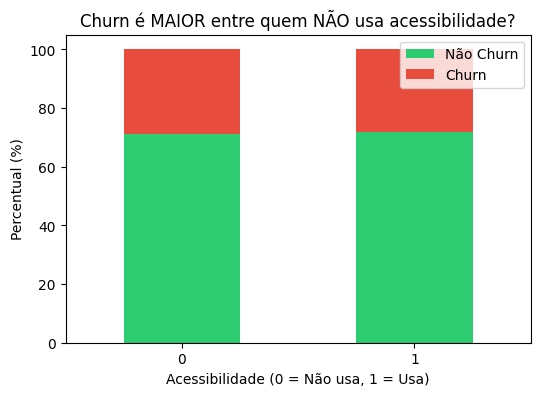

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tabela cruzada com percentuais
tab = pd.crosstab(df['acessibilidade'], df['churn'], normalize='index') * 100

print("=== TAXA DE CHURN POR USO DE ACESSIBILIDADE ===")
print(tab)

# Gráfico de barras (impacto visual imediato)
tab.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(6,4))
plt.title('Churn é MAIOR entre quem NÃO usa acessibilidade?')
plt.xlabel('Acessibilidade (0 = Não usa, 1 = Usa)')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(['Não Churn', 'Churn'])
plt.show()

In [13]:
pd.crosstab(df['acessibilidade'], df['churn'])

churn,0,1
acessibilidade,,
0,19833,8072
1,2478,968


In [14]:
# Filtra apenas o grupo de interesse
grupo_alvo = df[df['acessibilidade'] == 0]

# Lista de variáveis categóricas para analisar
cats = ['idade', 'genero', 'regiao', 'tipo_contrato', 'metodo_pagamento',
         'plano_assinatura', 'valor_mensal', 'tempo_assinatura_meses', 
         'dias_ultimo_acesso', 'acessibilidade', 'contatos_suporte', 
         'visualizacoes_mes', 'tempo_medio_sessao_min', 
         'dispositivo_principal', 'categoria_favorita', 
         'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 
         'avaliacao_plataforma']

print("=== TAXA DE CHURN DENTRO DO GRUPO 'acessibilidade = 0' ===")
print("(Ordenado da maior para a menor taxa de churn)\n")

for col in cats:
    # Calcula a taxa de churn por categoria
    tab = grupo_alvo.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    print(f"--- {col.upper()} ---")
    print(tab.round(1).astype(str) + '%')
    print()

=== TAXA DE CHURN DENTRO DO GRUPO 'acessibilidade = 0' ===
(Ordenado da maior para a menor taxa de churn)

--- IDADE ---
idade
20    40.0%
18    39.7%
24    38.1%
19    37.0%
72    36.9%
      ...  
56    21.8%
73    21.7%
58    20.4%
65    19.4%
84    17.5%
Name: churn, Length: 70, dtype: object

--- GENERO ---
genero
Outros                  30.3%
Feminino                29.6%
Não Informado           28.8%
Masculino               28.5%
Prefiro Não Informar    25.9%
Name: churn, dtype: object

--- REGIAO ---
regiao
Norte           32.5%
Nordeste        31.1%
Sul             28.1%
Sudeste         27.5%
Centro-Oeste    27.5%
Name: churn, dtype: object

--- TIPO_CONTRATO ---
tipo_contrato
Mensal    33.5%
Anual     18.6%
Name: churn, dtype: object

--- METODO_PAGAMENTO ---
metodo_pagamento
Pix                   34.0%
Débito                33.9%
Débito Automático     33.4%
Cartão de Crédito     32.9%
Boleto                31.4%
Crédito Recorrente    24.4%
Name: churn, dtype: object

--- PLA

In [15]:
# Filtro do grupo de altíssimo risco
grupo_critico = df[(df['acessibilidade'] == 0) & 
                   (df['plano_assinatura'] == 'Básico') & 
                   (df['visualizacoes_mes'] == 0)]

tx_churn_critico = grupo_critico['churn'].mean() * 100
total_critico = len(grupo_critico)
churns_critico = grupo_critico['churn'].sum()

print(f"=== PERFIL: Acessibilidade=0 + Plano Básico + 0 Visualizações ===")
print(f"Total de clientes nesse grupo: {total_critico}")
print(f"Taxa de Churn: {tx_churn_critico:.1f}%")
print(f"Churns capturados: {int(churns_critico)} clientes")

=== PERFIL: Acessibilidade=0 + Plano Básico + 0 Visualizações ===
Total de clientes nesse grupo: 38
Taxa de Churn: 92.1%
Churns capturados: 35 clientes


In [16]:
# Tabela de Regras de Negócio
regras = [
    ("Nível 1: Plano Básico + 0 Visualizações (já testado)", 
     (df['plano_assinatura'] == 'Básico') & (df['visualizacoes_mes'] == 0)),
    
    ("Nível 2: Plano Básico + Visualizações <= 2", 
     (df['plano_assinatura'] == 'Básico') & (df['visualizacoes_mes'] <= 2)),
    
    ("Nível 3: Plano Básico + Visualizações <= 5", 
     (df['plano_assinatura'] == 'Básico') & (df['visualizacoes_mes'] <= 5)),
    
    ("Nível 4: Qualquer plano + 0 Visualizações", 
     (df['visualizacoes_mes'] == 0))
]

print("=== REGRAS DE SEGMENTAÇÃO PARA AÇÃO DE RETENÇÃO ===")
print("(Todos os filtros já incluem implicitamente 'acessibilidade = 0')\n")

for nome, condicao in regras:
    grupo = df[(df['acessibilidade'] == 0) & condicao]
    total = len(grupo)
    churns = grupo['churn'].sum()
    tx = (churns / total * 100) if total > 0 else 0
    
    print(f"{nome}")
    print(f"  Clientes no grupo: {total}")
    print(f"  Churns capturados: {int(churns)}")
    print(f"  Taxa de Churn: {tx:.1f}%")
    print()

=== REGRAS DE SEGMENTAÇÃO PARA AÇÃO DE RETENÇÃO ===
(Todos os filtros já incluem implicitamente 'acessibilidade = 0')

Nível 1: Plano Básico + 0 Visualizações (já testado)
  Clientes no grupo: 38
  Churns capturados: 35
  Taxa de Churn: 92.1%

Nível 2: Plano Básico + Visualizações <= 2
  Clientes no grupo: 645
  Churns capturados: 362
  Taxa de Churn: 56.1%

Nível 3: Plano Básico + Visualizações <= 5
  Clientes no grupo: 1301
  Churns capturados: 691
  Taxa de Churn: 53.1%

Nível 4: Qualquer plano + 0 Visualizações
  Clientes no grupo: 121
  Churns capturados: 83
  Taxa de Churn: 68.6%



In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Filtra o grupo alvo
grupo = df[df['acessibilidade'] == 0].copy()

# Seleciona features categóricas mais promissoras (excluindo numéricas para simplificar)
features = ['plano_assinatura', 'tipo_contrato', 'visualizacoes_mes', 
            'dias_ultimo_acesso', 'contatos_suporte', 'genero', 'regiao']

# Codifica as variáveis categóricas como números para a árvore
for col in features:
    if grupo[col].dtype == 'object':
        grupo[col + '_enc'] = LabelEncoder().fit_transform(grupo[col].astype(str))
    else:
        grupo[col + '_enc'] = grupo[col]

# Prepara os dados
X = grupo[[col + '_enc' for col in features]]
y = grupo['churn']

# Árvore rasa para capturar as interações mais fortes (max_depth=3)
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=42)
tree.fit(X, y)

# Extrai regras da árvore em formato legível
from sklearn.tree import export_text
regras = export_text(tree, feature_names=features)
print("=== REGRAS DE ALTO RISCO (Caminhos da Árvore de Decisão) ===\n")
print(regras)

=== REGRAS DE ALTO RISCO (Caminhos da Árvore de Decisão) ===

|--- dias_ultimo_acesso <= 4.50
|   |--- dias_ultimo_acesso <= 2.50
|   |   |--- dias_ultimo_acesso <= 1.50
|   |   |   |--- class: 0
|   |   |--- dias_ultimo_acesso >  1.50
|   |   |   |--- class: 0
|   |--- dias_ultimo_acesso >  2.50
|   |   |--- plano_assinatura <= 0.50
|   |   |   |--- class: 0
|   |   |--- plano_assinatura >  0.50
|   |   |   |--- class: 0
|--- dias_ultimo_acesso >  4.50
|   |--- plano_assinatura <= 0.50
|   |   |--- tipo_contrato <= 0.50
|   |   |   |--- class: 0
|   |   |--- tipo_contrato >  0.50
|   |   |   |--- class: 1
|   |--- plano_assinatura >  0.50
|   |   |--- visualizacoes_mes <= 26.50
|   |   |   |--- class: 0
|   |   |--- visualizacoes_mes >  26.50
|   |   |   |--- class: 0



In [18]:
# Decodifica os valores do LabelEncoder para as variáveis relevantes
le_plano = LabelEncoder().fit(grupo['plano_assinatura'])
le_contrato = LabelEncoder().fit(grupo['tipo_contrato'])

print("=== TRADUÇÃO DA REGRA DE CHURN (Classe 1) ===")
print("Caminho:")
print("1. dias_ultimo_acesso > 4.50")
print(f"2. plano_assinatura <= 0.50 -> Categoria: {le_plano.inverse_transform([0])[0]}")
print(f"3. tipo_contrato > 0.50 -> Categoria: {le_contrato.inverse_transform([1])[0]}")
print("\nOu seja: Clientes com 'dias_ultimo_acesso' > 4, Plano Básico e Contrato Mensal.")

# Verifica a taxa de churn nesse grupo específico
grupo_regra = grupo[(grupo['dias_ultimo_acesso'] > 4.5) & 
                    (grupo['plano_assinatura'] == le_plano.inverse_transform([0])[0]) & 
                    (grupo['tipo_contrato'] == le_contrato.inverse_transform([1])[0])]
tx = grupo_regra['churn'].mean() * 100
total = len(grupo_regra)
churns = grupo_regra['churn'].sum()

print(f"\nTotal de clientes nessa regra: {total}")
print(f"Taxa de Churn: {tx:.1f}%")
print(f"Churns capturados: {int(churns)}")

=== TRADUÇÃO DA REGRA DE CHURN (Classe 1) ===
Caminho:
1. dias_ultimo_acesso > 4.50
2. plano_assinatura <= 0.50 -> Categoria: Básico
3. tipo_contrato > 0.50 -> Categoria: Mensal

Ou seja: Clientes com 'dias_ultimo_acesso' > 4, Plano Básico e Contrato Mensal.

Total de clientes nessa regra: 3845
Taxa de Churn: 55.4%
Churns capturados: 2131


In [19]:
print("=== PLANO BÁSICO + FAIXAS DE VISUALIZAÇÕES ===\n")
for limite in [0, 1, 2, 3, 4, 5, 10, 15]:
    cond = (df['acessibilidade'] == 0) & (df['plano_assinatura'] == 'Básico') & (df['visualizacoes_mes'] <= limite)
    grupo = df[cond]
    tx = grupo['churn'].mean() * 100
    total = len(grupo)
    churns = grupo['churn'].sum()
    print(f"<= {limite:2} views | Clientes: {total:5} | Churns: {int(churns):4} | Taxa: {tx:.1f}%")

=== PLANO BÁSICO + FAIXAS DE VISUALIZAÇÕES ===

<=  0 views | Clientes:    38 | Churns:   35 | Taxa: 92.1%
<=  1 views | Clientes:   287 | Churns:  179 | Taxa: 62.4%
<=  2 views | Clientes:   645 | Churns:  362 | Taxa: 56.1%
<=  3 views | Clientes:   903 | Churns:  490 | Taxa: 54.3%
<=  4 views | Clientes:  1123 | Churns:  607 | Taxa: 54.1%
<=  5 views | Clientes:  1301 | Churns:  691 | Taxa: 53.1%
<= 10 views | Clientes:  1985 | Churns: 1045 | Taxa: 52.6%
<= 15 views | Clientes:  2611 | Churns: 1373 | Taxa: 52.6%


In [20]:
# Cria faixas para variáveis contínuas (facilita a interpretação)
df['faixa_views'] = pd.cut(df['visualizacoes_mes'], bins=[-1, 0, 2, 5, 10, 100], labels=['0', '1-2', '3-5', '6-10', '11+'])
df['faixa_dias_ult_acesso'] = pd.cut(df['dias_ultimo_acesso'], bins=[-1, 2, 5, 10, 100], labels=['0-2', '3-5', '6-10', '11+'])

# Agrupa pelas features de interesse (somente acessibilidade = 0)
grupo = df[df['acessibilidade'] == 0]
resumo = grupo.groupby(['plano_assinatura', 'tipo_contrato', 'faixa_views', 'faixa_dias_ult_acesso'])['churn'].agg(
    total_clientes='count',
    churns='sum'
).reset_index()

resumo['taxa_churn'] = (resumo['churns'] / resumo['total_clientes'] * 100).round(1)
resumo = resumo.sort_values('churns', ascending=False).head(10)

print("=== TOP 10 GRUPOS COM MAIOR VOLUME DE CHURNS (Acessibilidade = 0) ===\n")
for i, row in resumo.iterrows():
    print(f"Plano: {row['plano_assinatura']:<8} | Contrato: {row['tipo_contrato']:<8} | Views: {row['faixa_views']:<5} | Dias último acesso: {row['faixa_dias_ult_acesso']:<5}")
    print(f"  -> Clientes: {row['total_clientes']:<5} | Churns: {int(row['churns']):<5} | Taxa: {row['taxa_churn']}%\n")

=== TOP 10 GRUPOS COM MAIOR VOLUME DE CHURNS (Acessibilidade = 0) ===

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 6-10 
  -> Clientes: 1458  | Churns: 732   | Taxa: 50.2%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 6-10 
  -> Clientes: 2172  | Churns: 696   | Taxa: 32.0%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 11+  
  -> Clientes: 1236  | Churns: 523   | Taxa: 42.3%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 11+  
  -> Clientes: 828   | Churns: 467   | Taxa: 56.4%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 3-5  
  -> Clientes: 1145  | Churns: 452   | Taxa: 39.5%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias último acesso: 3-5  
  -> Clientes: 1823  | Churns: 394   | Taxa: 21.6%

Plano: Premium  | Contrato: Mensal   | Views: 11+   | Dias último acesso: 6-10 
  -> Clientes: 1690  | Churns: 379   | Taxa: 22.4%

Plano

C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\2828277607.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = grupo.groupby(['plano_assinatura', 'tipo_contrato', 'faixa_views', 'faixa_dias_ult_acesso'])['churn'].agg(


In [21]:
# Combinação de Alto Risco e Volume Intermediário
grupo_estrategico = df[(df['acessibilidade'] == 0) & 
                       (df['plano_assinatura'] == 'Básico') & 
                       (df['visualizacoes_mes'].between(1, 5)) & 
                       (df['dias_ultimo_acesso'] > 10)]

tx = grupo_estrategico['churn'].mean() * 100
vol = len(grupo_estrategico)
ch = grupo_estrategico['churn'].sum()

print(f"Grupo: Básico + Views 1-5 + Dias > 10")
print(f"Clientes: {vol} | Churns: {int(ch)} | Taxa: {tx:.1f}%")

Grupo: Básico + Views 1-5 + Dias > 10
Clientes: 274 | Churns: 176 | Taxa: 64.2%


In [22]:
# Filtro base
base = df[df['acessibilidade'] == 0].copy()

# Agrupamento multidimensional (incluindo região e dispositivo)
grupos = base.groupby(['plano_assinatura', 'tipo_contrato', 
                       'faixa_views', 'faixa_dias_ult_acesso', 
                       'regiao', 'dispositivo_principal'])['churn'].agg(
    total='count',
    churns='sum'
).reset_index()

grupos['taxa_churn'] = (grupos['churns'] / grupos['total'] * 100).round(1)

# Filtra apenas grupos com volume mínimo razoável (ex: >50 clientes)
grupos_filtrados = grupos[grupos['total'] >= 50].sort_values('churns', ascending=False).head(5)

print("=== TOP 5 GRUPOS DE ALTO VOLUME DE CHURN (com Região e Dispositivo) ===\n")
for i, row in grupos_filtrados.iterrows():
    print(f"Plano: {row['plano_assinatura']:<8} | Contrato: {row['tipo_contrato']:<8} | Views: {row['faixa_views']:<5} | Dias: {row['faixa_dias_ult_acesso']:<5} | Região: {row['regiao']:<12} | Dispositivo: {row['dispositivo_principal']:<8}")
    print(f"  -> Clientes: {row['total']} | Churns: {int(row['churns'])} | Taxa: {row['taxa_churn']}%\n")

=== TOP 5 GRUPOS DE ALTO VOLUME DE CHURN (com Região e Dispositivo) ===

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias: 6-10  | Região: Sudeste      | Dispositivo: TV      
  -> Clientes: 332 | Churns: 99 | Taxa: 29.8%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10  | Região: Nordeste     | Dispositivo: TV      
  -> Clientes: 195 | Churns: 97 | Taxa: 49.7%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10  | Região: Sudeste      | Dispositivo: TV      
  -> Clientes: 181 | Churns: 95 | Taxa: 52.5%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias: 6-10  | Região: Nordeste     | Dispositivo: Mobile  
  -> Clientes: 225 | Churns: 90 | Taxa: 40.0%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias: 6-10  | Região: Nordeste     | Dispositivo: TV      
  -> Clientes: 234 | Churns: 79 | Taxa: 33.8%



C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\639437855.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos = base.groupby(['plano_assinatura', 'tipo_contrato',


In [23]:
# Filtra grupos com volume mínimo de 10 clientes para relevância estatística
grupos_pequenos = grupos[grupos['total'] >= 10].sort_values('taxa_churn', ascending=False).head(5)

print("=== TOP 5 GRUPOS POR MAIOR TAXA DE CHURN (Volume >= 10 clientes) ===\n")
for i, row in grupos_pequenos.iterrows():
    print(f"Plano: {row['plano_assinatura']:<8} | Contrato: {row['tipo_contrato']:<8} | Views: {row['faixa_views']:<5} | Dias: {row['faixa_dias_ult_acesso']:<5} | Região: {row['regiao']:<12} | Dispositivo: {row['dispositivo_principal']:<8}")
    print(f"  -> Clientes: {row['total']} | Churns: {int(row['churns'])} | Taxa: {row['taxa_churn']}%\n")

=== TOP 5 GRUPOS POR MAIOR TAXA DE CHURN (Volume >= 10 clientes) ===

Plano: Básico   | Contrato: Mensal   | Views: 3-5   | Dias: 11+   | Região: Nordeste     | Dispositivo: Mobile  
  -> Clientes: 20 | Churns: 17 | Taxa: 85.0%

Plano: Padrão   | Contrato: Mensal   | Views: 1-2   | Dias: 6-10  | Região: Sul          | Dispositivo: Mobile  
  -> Clientes: 12 | Churns: 10 | Taxa: 83.3%

Plano: Básico   | Contrato: Mensal   | Views: 6-10  | Dias: 11+   | Região: Sudeste      | Dispositivo: Mobile  
  -> Clientes: 12 | Churns: 10 | Taxa: 83.3%

Plano: Básico   | Contrato: Mensal   | Views: 1-2   | Dias: 11+   | Região: Sudeste      | Dispositivo: Mobile  
  -> Clientes: 11 | Churns: 9 | Taxa: 81.8%

Plano: Básico   | Contrato: Mensal   | Views: 3-5   | Dias: 6-10  | Região: Sudeste      | Dispositivo: Mobile  
  -> Clientes: 24 | Churns: 19 | Taxa: 79.2%



In [24]:
# Agrupamento com categoria_favorita
grupos_cat = base.groupby(['plano_assinatura', 'tipo_contrato', 
                           'faixa_views', 'faixa_dias_ult_acesso', 
                           'regiao', 'dispositivo_principal', 
                           'categoria_favorita'])['churn'].agg(
    total='count',
    churns='sum'
).reset_index()

grupos_cat['taxa_churn'] = (grupos_cat['churns'] / grupos_cat['total'] * 100).round(1)

# Filtra relevância estatística mínima (10 clientes) e ordena por taxa
top_taxa_cat = grupos_cat[grupos_cat['total'] >= 10].sort_values('taxa_churn', ascending=False).head(5)

print("=== TOP 5 MAIORES TAXAS DE CHURN (incluindo Categoria Favorita) ===\n")
for i, row in top_taxa_cat.iterrows():
    print(f"Plano: {row['plano_assinatura']:<8} | Contrato: {row['tipo_contrato']:<8} | Views: {row['faixa_views']:<5} | Dias: {row['faixa_dias_ult_acesso']:<5}")
    print(f"Região: {row['regiao']:<12} | Dispositivo: {row['dispositivo_principal']:<8} | Categoria: {row['categoria_favorita']:<15}")
    print(f"  -> Clientes: {row['total']} | Churns: {int(row['churns'])} | Taxa: {row['taxa_churn']}%\n")

C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\1279926266.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos_cat = base.groupby(['plano_assinatura', 'tipo_contrato',


=== TOP 5 MAIORES TAXAS DE CHURN (incluindo Categoria Favorita) ===

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 11+  
Região: Nordeste     | Dispositivo: Tablet   | Categoria: Séries         
  -> Clientes: 15 | Churns: 12 | Taxa: 80.0%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 11+  
Região: Nordeste     | Dispositivo: Mobile   | Categoria: Documentários  
  -> Clientes: 10 | Churns: 8 | Taxa: 80.0%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10 
Região: Sul          | Dispositivo: Mobile   | Categoria: Séries         
  -> Clientes: 17 | Churns: 13 | Taxa: 76.5%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 11+  
Região: Nordeste     | Dispositivo: TV       | Categoria: Esportes       
  -> Clientes: 16 | Churns: 12 | Taxa: 75.0%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10 
Região: Norte        | Dispositivo: Mobile   | Categoria: Séries         
  -> Clientes: 12 | Churns: 9 | Taxa: 75.0%



In [25]:
# Cria faixa para contatos_suporte
base['faixa_suporte'] = pd.cut(base['contatos_suporte'], bins=[-1, 0, 2, 5, 100], labels=['0', '1-2', '3-5', '6+'])

# Agrupamento completo
grupos_full = base.groupby(['plano_assinatura', 'tipo_contrato', 
                            'faixa_views', 'faixa_dias_ult_acesso', 
                            'regiao', 'dispositivo_principal', 
                            'categoria_favorita', 'faixa_suporte'])['churn'].agg(
    total='count',
    churns='sum'
).reset_index()

grupos_full['taxa_churn'] = (grupos_full['churns'] / grupos_full['total'] * 100).round(1)

# Top 5 maiores taxas com volume >= 10
top_full = grupos_full[grupos_full['total'] >= 10].sort_values('taxa_churn', ascending=False).head(5)

print("=== TOP 5 MAIORES TAXAS DE CHURN (incluindo Contatos Suporte) ===\n")
for i, row in top_full.iterrows():
    print(f"Plano: {row['plano_assinatura']:<8} | Contrato: {row['tipo_contrato']:<8} | Views: {row['faixa_views']:<5} | Dias: {row['faixa_dias_ult_acesso']:<5}")
    print(f"Região: {row['regiao']:<12} | Dispositivo: {row['dispositivo_principal']:<8} | Categoria: {row['categoria_favorita']:<15} | Suporte: {row['faixa_suporte']:<5}")
    print(f"  -> Clientes: {row['total']} | Churns: {int(row['churns'])} | Taxa: {row['taxa_churn']}%\n")

C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\3541973361.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupos_full = base.groupby(['plano_assinatura', 'tipo_contrato',


=== TOP 5 MAIORES TAXAS DE CHURN (incluindo Contatos Suporte) ===

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10 
Região: Sudeste      | Dispositivo: Desktop  | Categoria: Séries          | Suporte: 0    
  -> Clientes: 10 | Churns: 8 | Taxa: 80.0%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias: 6-10 
Região: Nordeste     | Dispositivo: Mobile   | Categoria: Filmes          | Suporte: 0    
  -> Clientes: 13 | Churns: 10 | Taxa: 76.9%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 3-5  
Região: Nordeste     | Dispositivo: Mobile   | Categoria: Séries          | Suporte: 1-2  
  -> Clientes: 11 | Churns: 8 | Taxa: 72.7%

Plano: Básico   | Contrato: Mensal   | Views: 11+   | Dias: 6-10 
Região: Sul          | Dispositivo: Mobile   | Categoria: Séries          | Suporte: 1-2  
  -> Clientes: 10 | Churns: 7 | Taxa: 70.0%

Plano: Padrão   | Contrato: Mensal   | Views: 11+   | Dias: 11+  
Região: Sudeste      | Dispositivo: TV       | Categoria: 

In [26]:
# Cria quartis de idade
df['quartil_idade'] = pd.qcut(df['idade'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Agrupa por quartil
resumo_idade = df.groupby('quartil_idade')['churn'].agg(
    total_clientes='count',
    churns='sum'
).reset_index()
resumo_idade['taxa_churn'] = (resumo_idade['churns'] / resumo_idade['total_clientes'] * 100).round(1)

# Comparação com idade=20
idade_20 = df[df['idade'] == 20]
tx_20 = idade_20['churn'].mean() * 100
vol_20 = len(idade_20)

print("=== ANÁLISE DE DENSIDADE DE RISCO: IDADE ===\n")
print(resumo_idade.to_string(index=False))
print(f"\nComparação: Idade=20 isolada -> Clientes: {vol_20} | Taxa: {tx_20:.1f}%")

=== ANÁLISE DE DENSIDADE DE RISCO: IDADE ===

quartil_idade  total_clientes  churns  taxa_churn
           Q1            8866    2705        30.5
           Q2            7897    2282        28.9
           Q3            6811    1941        28.5
           Q4            7777    2112        27.2

Comparação: Idade=20 isolada -> Clientes: 90 | Taxa: 40.0%


C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\2547007214.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo_idade = df.groupby('quartil_idade')['churn'].agg(


In [27]:
# Cria quartis de tempo_assinatura_meses
df['quartil_tempo'] = pd.qcut(df['tempo_assinatura_meses'], q=4, labels=['Q1_Recente', 'Q2', 'Q3', 'Q4_Antigo'])

resumo_tempo = df.groupby('quartil_tempo')['churn'].agg(
    total_clientes='count',
    churns='sum'
).reset_index()
resumo_tempo['taxa_churn'] = (resumo_tempo['churns'] / resumo_tempo['total_clientes'] * 100).round(1)

print("=== DENSIDADE DE RISCO: TEMPO DE ASSINATURA ===\n")
print(resumo_tempo.to_string(index=False))

=== DENSIDADE DE RISCO: TEMPO DE ASSINATURA ===

quartil_tempo  total_clientes  churns  taxa_churn
   Q1_Recente            8687    2426        27.9
           Q2            7831    2327        29.7
           Q3            7595    2215        29.2
    Q4_Antigo            7238    2072        28.6


C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\2820454587.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo_tempo = df.groupby('quartil_tempo')['churn'].agg(


In [28]:
# Cria faixas personalizadas para visualizacoes_mes (baseado na distribuição real)
df['faixa_views_densidade'] = pd.cut(df['visualizacoes_mes'], 
                                     bins=[-1, 0, 5, 15, 50, 100], 
                                     labels=['0', '1-5', '6-15', '16-50', '51+'])

resumo_views = df.groupby('faixa_views_densidade', observed=False)['churn'].agg(
    total_clientes='count',
    churns='sum'
).reset_index()
resumo_views['taxa_churn'] = (resumo_views['churns'] / resumo_views['total_clientes'] * 100).round(1)

print("=== DENSIDADE DE RISCO: VISUALIZAÇÕES POR MÊS ===\n")
print(resumo_views.to_string(index=False))

=== DENSIDADE DE RISCO: VISUALIZAÇÕES POR MÊS ===

faixa_views_densidade  total_clientes  churns  taxa_churn
                    0             135      94        69.6
                  1-5            5684    2087        36.7
                 6-15            5297    1954        36.9
                16-50           17515    4538        25.9
                  51+            2720     367        13.5


In [29]:
# Filtra o grupo de alta densidade cruzada
grupo_denso = df[(df['quartil_idade'] == 'Q1') & (df['faixa_views_densidade'].isin(['1-5', '6-15']))]

total = len(grupo_denso)
churns = grupo_denso['churn'].sum()
tx = churns / total * 100

print(f"=== GRUPO DE ALTÍSSIMA DENSIDADE DE RISCO ===")
print(f"Filtro: Idade Q1 (jovens) + Views entre 1 e 15")
print(f"Clientes: {total}")
print(f"Churns Absolutos: {int(churns)}")
print(f"Taxa de Churn: {tx:.1f}%")
print(f"\nEste grupo sozinho representa {churns/df['churn'].sum()*100:.1f}% de todos os churns da base.")

=== GRUPO DE ALTÍSSIMA DENSIDADE DE RISCO ===
Filtro: Idade Q1 (jovens) + Views entre 1 e 15
Clientes: 3103
Churns Absolutos: 1199
Taxa de Churn: 38.6%

Este grupo sozinho representa 13.3% de todos os churns da base.


In [30]:
# Refinando com acessibilidade = 0
grupo_denso_refinado = df[(df['quartil_idade'] == 'Q1') & 
                          (df['faixa_views_densidade'].isin(['1-5', '6-15'])) & 
                          (df['acessibilidade'] == 0)]

total_ref = len(grupo_denso_refinado)
churns_ref = grupo_denso_refinado['churn'].sum()
tx_ref = churns_ref / total_ref * 100 if total_ref > 0 else 0

print(f"=== GRUPO DENSO REFINADO (com acessibilidade = 0) ===")
print(f"Filtro: Idade Q1 + Views 1-15 + Sem Acessibilidade")
print(f"Clientes: {total_ref}")
print(f"Churns Absolutos: {int(churns_ref)}")
print(f"Taxa de Churn: {tx_ref:.1f}%")
print(f"Representa {churns_ref/df['churn'].sum()*100:.1f}% de todos os churns da base.")

=== GRUPO DENSO REFINADO (com acessibilidade = 0) ===
Filtro: Idade Q1 + Views 1-15 + Sem Acessibilidade
Clientes: 2830
Churns Absolutos: 1085
Taxa de Churn: 38.3%
Representa 12.0% de todos os churns da base.


In [31]:
# Grupo de baixíssimo risco (fiéis)
# Usando características opostas: Q4 (mais velhos) + Views 51+ + acessibilidade = 1
grupo_fiel = df[(df['quartil_idade'] == 'Q4') & 
                (df['faixa_views_densidade'] == '51+') & 
                (df['acessibilidade'] == 1)]

total_fiel = len(grupo_fiel)
churns_fiel = grupo_fiel['churn'].sum()
tx_fiel = churns_fiel / total_fiel * 100 if total_fiel > 0 else 0

print(f"\n=== GRUPO DE CLIENTES FIÉIS (Baixo Churn) ===")
print(f"Filtro: Idade Q4 + Views 51+ + Com Acessibilidade")
print(f"Clientes: {total_fiel}")
print(f"Churns: {int(churns_fiel)}")
print(f"Taxa de Churn: {tx_fiel:.1f}%")


=== GRUPO DE CLIENTES FIÉIS (Baixo Churn) ===
Filtro: Idade Q4 + Views 51+ + Com Acessibilidade
Clientes: 109
Churns: 16
Taxa de Churn: 14.7%


<Axes: xlabel='genero'>

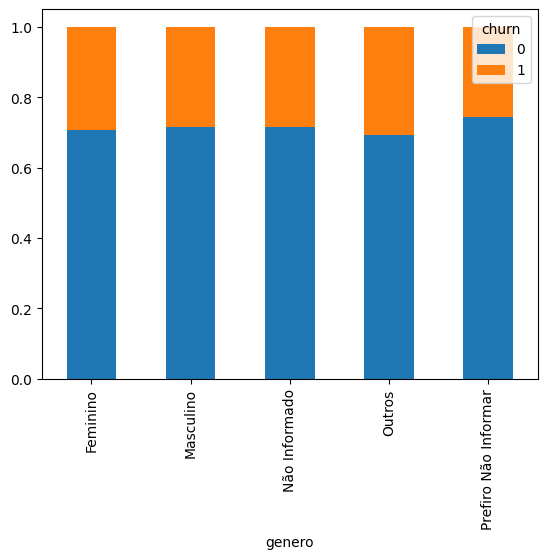

In [32]:
grafico = px.histogram(tabela, x="churn", color="genero", title="Distribuição de Churn")
grafico.show() # MOSTRA CONTAGEM ABSOLUTA(é influenciada pelo tamanho de cada grupo.)

(pd.crosstab(df['genero'], df['churn'], normalize='index')
   .plot(kind='bar', stacked=True)) # MOSTRA TAXAS

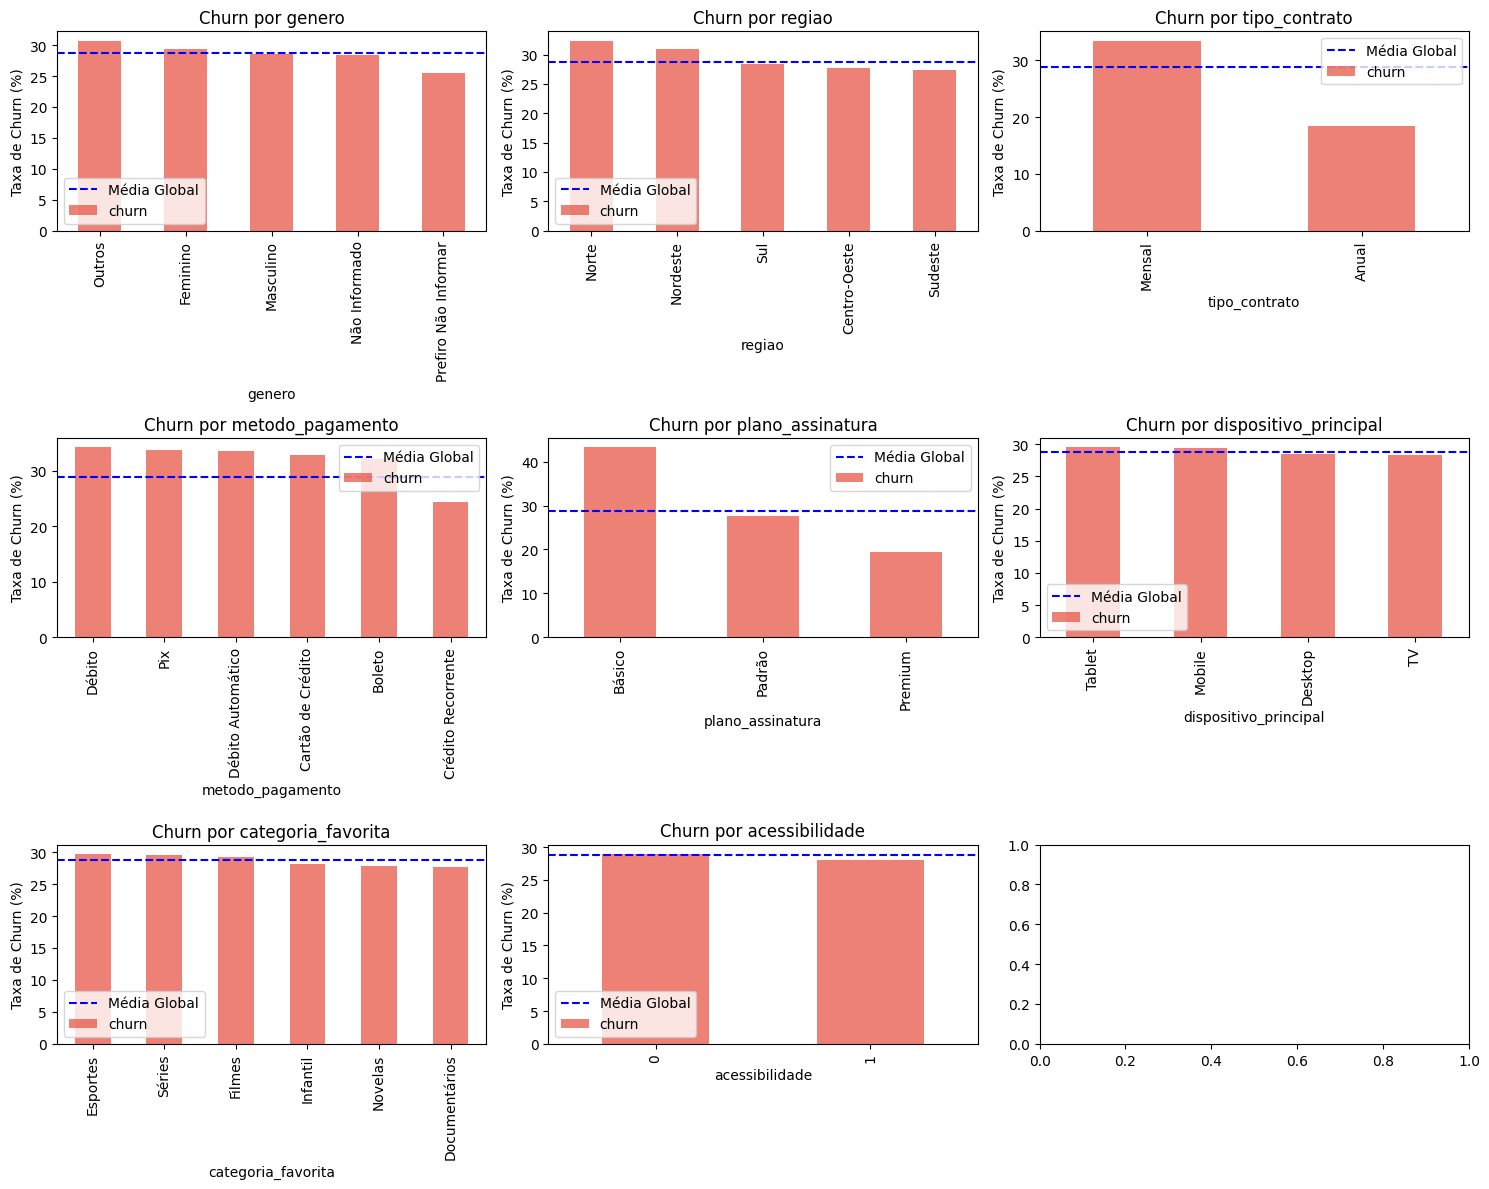

In [33]:
import matplotlib.pyplot as plt

# Seleciona apenas categóricas (exclui numéricas para não poluir)
cats = ['genero', 'regiao', 'tipo_contrato', 'metodo_pagamento', 
        'plano_assinatura', 'dispositivo_principal', 'categoria_favorita', 'acessibilidade']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cats):
    if i < len(axes):
        # Calcula taxa de churn por categoria
        tx_churn = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
        tx_churn.plot(kind='bar', ax=axes[i], color='#e74c3c', alpha=0.7)
        axes[i].set_title(f'Churn por {col}')
        axes[i].set_ylabel('Taxa de Churn (%)')
        axes[i].axhline(y=28.8, color='blue', linestyle='--', label='Média Global')
        axes[i].legend()

plt.tight_layout()
plt.show()

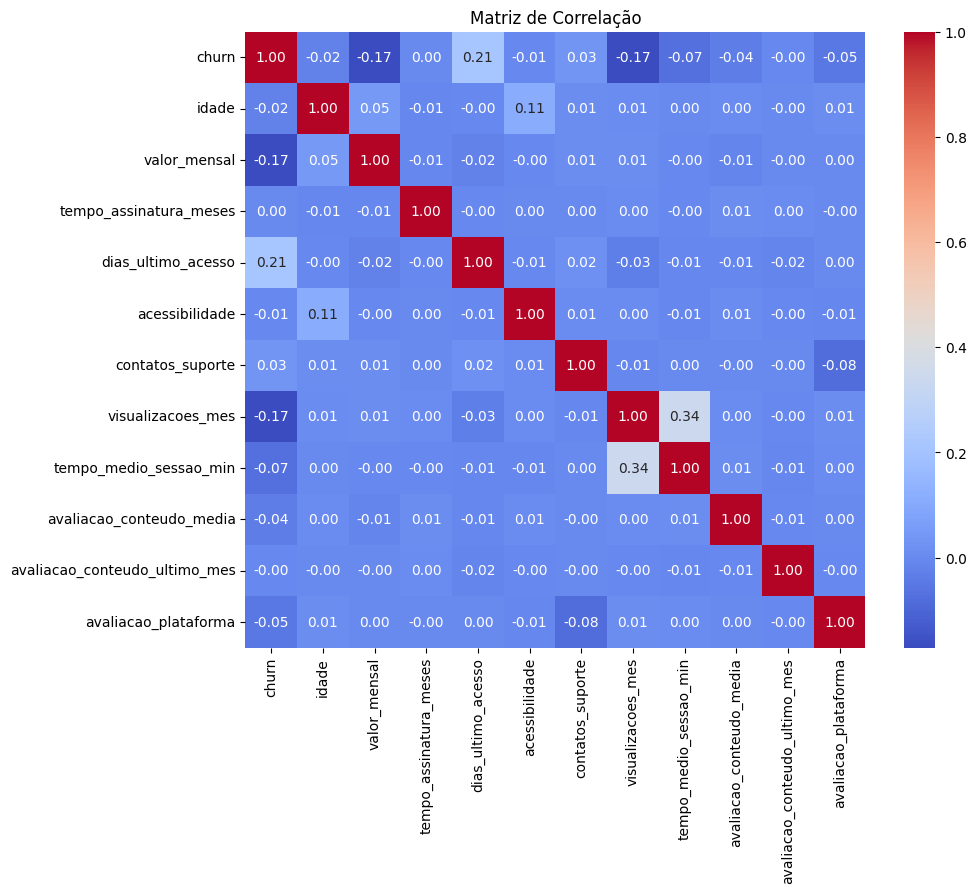

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selecionar apenas colunas numéricas (incluindo churn, acessibilidade, avaliações etc.)
numeric_cols = tabela.select_dtypes(include=['int64', 'float64'])

# 2. Matriz de correlação (Pearson por padrão)
corr_matrix = numeric_cols.corr()

# 3. Visualizar com heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [35]:
vars_missing = ['genero', 'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']

for var in vars_missing:
    tabela[f'missing_{var}'] = tabela[var].isna()
    print(f"\n=== {var.upper()} ===")
    print("Churn:", tabela.groupby(f'missing_{var}')['churn'].mean())
    print("Acessibilidade:", tabela.groupby(f'missing_{var}')['acessibilidade'].mean())
    print("Visualizações:", tabela.groupby(f'missing_{var}')['visualizacoes_mes'].mean())
# "Evidência de MCAR para churn; missing associado a menor atividade (views), mas sem viés de churn."
#Isso documenta que a imputação simples não introduz viés para o target churn.


=== GENERO ===
Churn: missing_genero
False    0.288810
True     0.284475
Name: churn, dtype: float64
Acessibilidade: missing_genero
False    0.109826
True     0.110679
Name: acessibilidade, dtype: float64
Visualizações: missing_genero
False    23.939482
True     23.762190
Name: visualizacoes_mes, dtype: float64

=== AVALIACAO_CONTEUDO_MEDIA ===
Churn: missing_avaliacao_conteudo_media
False    0.288005
True     0.289221
Name: churn, dtype: float64
Acessibilidade: missing_avaliacao_conteudo_media
False    0.109551
True     0.110847
Name: acessibilidade, dtype: float64
Visualizações: missing_avaliacao_conteudo_media
False    24.414260
True     22.663613
Name: visualizacoes_mes, dtype: float64

=== AVALIACAO_CONTEUDO_ULTIMO_MES ===
Churn: missing_avaliacao_conteudo_ultimo_mes
False    0.288173
True     0.288651
Name: churn, dtype: float64
Acessibilidade: missing_avaliacao_conteudo_ultimo_mes
False    0.109562
True     0.110530
Name: acessibilidade, dtype: float64
Visualizações: missing_av

In [36]:
# Lista de variáveis com missing original
vars_missing = ['genero', 'avaliacao_conteudo_media', 
                'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']

# Cria as flags de missing (se ainda não existirem)
for var in vars_missing:
    if f'missing_{var}' not in df.columns:
        df[f'missing_{var}'] = df[var].isna()

# Constrói um DataFrame resumo
resumo_missing = pd.DataFrame()

for var in vars_missing:
    flag = f'missing_{var}'
    agg = df.groupby(flag).agg(
        churn_mean=('churn', 'mean'),
        acessibilidade_mean=('acessibilidade', 'mean'),
        views_mean=('visualizacoes_mes', 'mean')
    ).reset_index()
    agg['variavel'] = var
    agg = agg.rename(columns={flag: 'missing'})
    resumo_missing = pd.concat([resumo_missing, agg], ignore_index=True)

# Reorganiza para exibição clara
resumo_missing = resumo_missing[['variavel', 'missing', 'churn_mean', 
                                 'acessibilidade_mean', 'views_mean']]
resumo_missing['missing'] = resumo_missing['missing'].map({False: 'Preenchido', True: 'Faltante'})

print(resumo_missing.to_string(index=False))

                     variavel    missing  churn_mean  acessibilidade_mean  views_mean
                       genero Preenchido    0.288348             0.109917   23.920577
     avaliacao_conteudo_media Preenchido    0.288348             0.109917   23.920577
avaliacao_conteudo_ultimo_mes Preenchido    0.288348             0.109917   23.920577
         avaliacao_plataforma Preenchido    0.288348             0.109917   23.920577


In [37]:
from scipy.stats import ttest_ind

vars_missing = ['genero', 'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']

for var in vars_missing:
    missing = tabela[f'missing_{var}']
    
    # Separar grupos
    grupo0 = tabela[missing == False]['visualizacoes_mes']  # tem valor
    grupo1 = tabela[missing == True]['visualizacoes_mes']   # missing
    
    # Teste t
    stat, p_value = ttest_ind(grupo0, grupo1)
    
    print(f"\n=== {var.upper()} ===")
    print(f"p-valor visualizações: {p_value:.4f}")
    print("✅ MCAR se p > 0.05 | ⚠️ MAR se p < 0.05")


=== GENERO ===
p-valor visualizações: 0.5725
✅ MCAR se p > 0.05 | ⚠️ MAR se p < 0.05

=== AVALIACAO_CONTEUDO_MEDIA ===
p-valor visualizações: 0.0000
✅ MCAR se p > 0.05 | ⚠️ MAR se p < 0.05

=== AVALIACAO_CONTEUDO_ULTIMO_MES ===
p-valor visualizações: 0.0000
✅ MCAR se p > 0.05 | ⚠️ MAR se p < 0.05

=== AVALIACAO_PLATAFORMA ===
p-valor visualizações: 0.0000
✅ MCAR se p > 0.05 | ⚠️ MAR se p < 0.05


In [38]:
from scipy.stats import ttest_ind
import pandas as pd

vars_missing = ['genero', 'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']

print("LITTLE'S MCAR - TESTE SIMPLIFICADO")
print("="*50)

for var in vars_missing:
    # Testar missing vs churn E acessibilidade E visualizações
    missing = tabela[f'missing_{var}']
    
    churn_p = tabela.groupby(missing)['churn'].mean()
    acess_p = tabela.groupby(missing)['acessibilidade'].mean() 
    viz_p = tabela.groupby(missing)['visualizacoes_mes'].mean()
    
    # Teste t em visualizações (mais sensível)
    grupo0 = tabela[missing == False]['visualizacoes_mes']
    grupo1 = tabela[missing == True]['visualizacoes_mes']
    stat, p_viz = ttest_ind(grupo0, grupo1)
    
    print(f"\n{var.upper()}:")
    print(f"  Churn:     {churn_p.values} (dif {((churn_p.iloc[1]-churn_p.iloc[0])/churn_p.iloc[0]*100):+.1f}%)")
    print(f"  Acessib:   {acess_p.values} (dif {((acess_p.iloc[1]-acess_p.iloc[0])/acess_p.iloc[0]*100):+.1f}%)")
    print(f"  Viz mês:   {viz_p.values} (dif {((viz_p.iloc[1]-viz_p.iloc[0])/viz_p.iloc[0]*100):+.1f}%)")
    print(f"  p-valor:   {p_viz:.4f} → {'✅ MCAR' if p_viz > 0.05 else '❌ MAR'}")

LITTLE'S MCAR - TESTE SIMPLIFICADO

GENERO:
  Churn:     [0.28881034 0.28447502] (dif -1.5%)
  Acessib:   [0.10982576 0.11067903] (dif +0.8%)
  Viz mês:   [23.93948158 23.76218965] (dif -0.7%)
  p-valor:   0.5725 → ✅ MCAR

AVALIACAO_CONTEUDO_MEDIA:
  Churn:     [0.28800533 0.28922068] (dif +0.4%)
  Acessib:   [0.10955131 0.11084719] (dif +1.2%)
  Viz mês:   [24.41426033 22.66361271] (dif -7.2%)
  p-valor:   0.0000 → ❌ MAR

AVALIACAO_CONTEUDO_ULTIMO_MES:
  Churn:     [0.28817313 0.28865081] (dif +0.2%)
  Acessib:   [0.10956215 0.11053044] (dif +0.9%)
  Viz mês:   [24.56421741 22.80663705] (dif -7.2%)
  p-valor:   0.0000 → ❌ MAR

AVALIACAO_PLATAFORMA:
  Churn:     [0.28736778 0.28967955] (dif +0.8%)
  Acessib:   [0.10771446 0.11290808] (dif +4.8%)
  Viz mês:   [24.69635045 22.86685723] (dif -7.4%)
  p-valor:   0.0000 → ❌ MAR


In [39]:
# 1. Criar as 3 versões da feature
tabela['missing_flag'] = tabela['avaliacao_plataforma'].isna().astype(int)
tabela['imputacao_media'] = tabela['avaliacao_plataforma'].fillna(tabela['avaliacao_plataforma'].mean())
tabela['imputacao_zero'] = tabela['avaliacao_plataforma'].fillna(0)

# 2. Correlação com churn (quanto maior, melhor)
print("CORRELAÇÃO COM CHURN:")
print(f"Missing flag:     {tabela['missing_flag'].corr(tabela['churn']):.4f}")
print(f"Imputação média:  {tabela['imputacao_media'].corr(tabela['churn']):.4f}")
print(f"Imputação zero:   {tabela['imputacao_zero'].corr(tabela['churn']):.4f}")

CORRELAÇÃO COM CHURN:
Missing flag:     0.0025
Imputação média:  -0.0361
Imputação zero:   -0.0165


In [40]:
# Regressão logística simples (R²)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X1 = tabela[['missing_flag']].fillna(0)
X2 = tabela[['imputacao_media']].fillna(0)
y = tabela['churn']

model1 = LogisticRegression().fit(X1, y)
model2 = LogisticRegression().fit(X2, y)

print(f"Missing flag AUC: {roc_auc_score(y, model1.predict_proba(X1)[:,1]):.4f}")
print(f"Imputação AUC:    {roc_auc_score(y, model2.predict_proba(X2)[:,1]):.4f}")

Missing flag AUC: 0.5014
Imputação AUC:    0.5216


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# Features selecionadas (baseadas na nossa exploração)
features = ['visualizacoes_mes', 'dias_ultimo_acesso', 'valor_mensal',
            'plano_assinatura', 'tipo_contrato', 'acessibilidade', 
            'idade', 'avaliacao_conteudo_media', 'avaliacao_plataforma']

# Remove linhas com NaN nas features selecionadas (já tratamos, mas por segurança)
df_model = df[features + ['churn']].dropna()

X = df_model[features]
y = df_model['churn']

# Divide treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pipeline para variáveis numéricas e categóricas
num_cols = ['visualizacoes_mes', 'dias_ultimo_acesso', 'valor_mensal', 'idade',
            'avaliacao_conteudo_media', 'avaliacao_plataforma']
cat_cols = ['plano_assinatura', 'tipo_contrato', 'acessibilidade']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

model = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC no teste: {auc:.4f}")

AUC no teste: 0.7216


In [42]:
# Feature engineering PRO
tabela['missing_avaliacoes_totais'] = (
    tabela['missing_avaliacao_conteudo_media'] + 
    tabela['missing_avaliacao_conteudo_ultimo_mes'] + 
    tabela['missing_avaliacao_plataforma']
)

# Features finais para XGBoost churn:
features_finais = [
    'missing_avaliacoes_totais',  # ← SUA DESCOBERTA!
    'acessibilidade', 
    'visualizacoes_mes',
    'dias_ultimo_acesso'
]

In [43]:
# Correlação com churn
print(f"Correlação missing_avaliacoes_totais vs churn: {tabela['missing_avaliacoes_totais'].corr(tabela['churn']):.4f}")

# AUC isolada
from sklearn.metrics import roc_auc_score
X = tabela[['missing_avaliacoes_totais']].fillna(0)
model = LogisticRegression().fit(X, tabela['churn'])
print(f"AUC isolada: {roc_auc_score(tabela['churn'], model.predict_proba(X)[:,1]):.4f}")

Correlação missing_avaliacoes_totais vs churn: 0.0018
AUC isolada: 0.5009


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Features finais (baseadas em TODA nossa exploração conjunta)
num_features = [
    'visualizacoes_mes',
    'dias_ultimo_acesso',
    'valor_mensal',
    'idade',
    'tempo_medio_sessao_min',
    'contatos_suporte',
    'missing_avaliacoes_totais',          # Sua descoberta
    'avaliacao_conteudo_media',           # Imputada com mediana
    'avaliacao_conteudo_ultimo_mes',      # Imputada com mediana
    'avaliacao_plataforma'                # Imputada com mediana
]

cat_features = [
    'plano_assinatura',
    'tipo_contrato',
    'acessibilidade',
    'genero'                               # Imputado com "Não Informado"
]

# Prepara dados (sem NaN)
df_model = tabela[num_features + cat_features + ['churn']].copy()
df_model = df_model.dropna()  # Garantia extra

X = df_model[num_features + cat_features]
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pipeline com pré-processamento adequado
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

# Modelos
models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

print("🏆 BATALHA DE MODELOS - CHURN PREDIÇÃO (Features atualizadas)")
print("="*60)

results = {}
for nome, model in models.items():
    pipe = Pipeline([
        ('preproc', preprocessor),
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred_proba = pipe.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[nome] = auc
    print(f"{nome:12}: AUC = {auc:.4f}")

ranking = sorted(results.items(), key=lambda x: x[1], reverse=True)
print(f"\n🏅 Campeão: {ranking[0][0]} (AUC: {ranking[0][1]:.4f})")

🏆 BATALHA DE MODELOS - CHURN PREDIÇÃO (Features atualizadas)
Logistic    : AUC = 0.7318
RandomForest: AUC = 0.7141
XGBoost     : AUC = 0.7050

🏅 Campeão: Logistic (AUC: 0.7318)


🏆 IMPORTÂNCIA - LOGISTIC (COEFICIENTES):
                      feature  coefficient
         tipo_contrato_Mensal     0.964640
                 valor_mensal    -0.553237
            visualizacoes_mes    -0.472836
           dias_ultimo_acesso     0.462357
  genero_Prefiro Não Informar    -0.449785
     plano_assinatura_Premium     0.231661
      plano_assinatura_Padrão     0.201892
                genero_Outros     0.186151
             acessibilidade_1     0.142080
     avaliacao_conteudo_media    -0.114672
             contatos_suporte     0.081433
         avaliacao_plataforma    -0.067626
             genero_Masculino    -0.061401
       tempo_medio_sessao_min    -0.048559
                        idade    -0.031668
avaliacao_conteudo_ultimo_mes     0.000153
    missing_avaliacoes_totais     0.000000


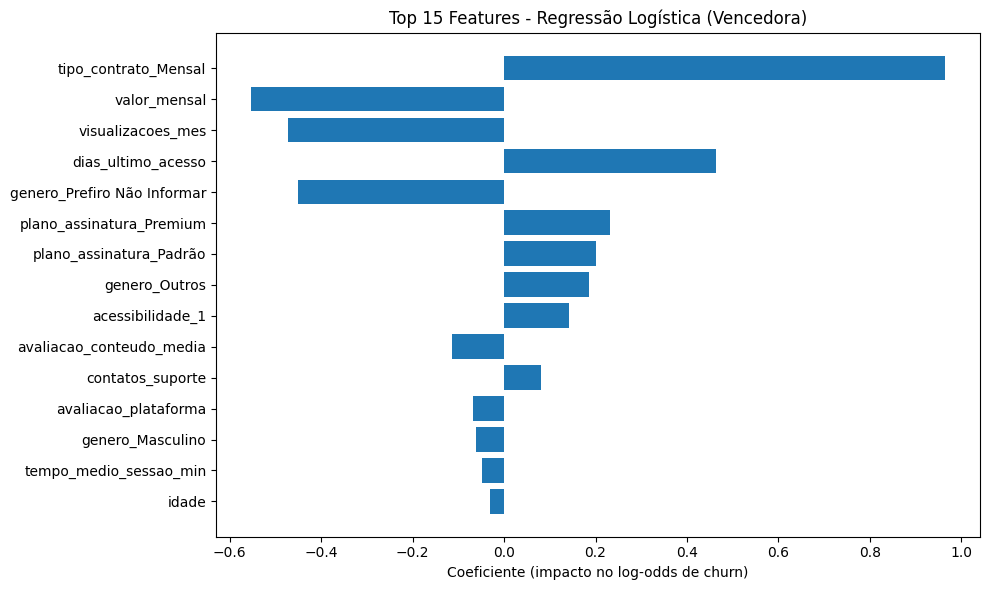

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Recupera o melhor modelo (Logistic) do dicionário 'models' e aplica o pipeline
best_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', models['Logistic'])
])
best_pipe.fit(X_train, y_train)

# Obtém os nomes das features após OneHotEncoding
preproc = best_pipe.named_steps['preproc']
cat_encoder = preproc.named_transformers_['cat']
num_features_names = num_features
cat_features_names = list(cat_encoder.get_feature_names_out(cat_features))

all_features = num_features_names + cat_features_names

# Coeficientes do modelo logístico
coefficients = best_pipe.named_steps['clf'].coef_[0]

# Cria DataFrame de importância
coef_df = pd.DataFrame({
    'feature': all_features,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

print("🏆 IMPORTÂNCIA - LOGISTIC (COEFICIENTES):")
print(coef_df.to_string(index=False))

# Gráfico de barras horizontais (top 15 features para não poluir)
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'].head(top_n)[::-1], coef_df['coefficient'].head(top_n)[::-1])
plt.title(f'Top {top_n} Features - Regressão Logística (Vencedora)')
plt.xlabel('Coeficiente (impacto no log-odds de churn)')
plt.tight_layout()
plt.show()

In [46]:
# Evita divisão por zero (0 views -> máximo de abandono)
tabela['razao_abandono'] = tabela['dias_ultimo_acesso'] / (tabela['visualizacoes_mes'] + 1)

# Alternativa: flag binária para o grupo crítico que já validamos
tabela['flag_abandono_critico'] = (
    (tabela['dias_ultimo_acesso'] > 10) & 
    (tabela['visualizacoes_mes'].between(1, 5))
).astype(int)

In [47]:
# 1. Cria a nova feature no DataFrame original
tabela['razao_abandono'] = tabela['dias_ultimo_acesso'] / (tabela['visualizacoes_mes'] + 1)

# 2. Recria o df_model com a nova coluna
num_features_v2 = num_features + ['razao_abandono']
df_model_v2 = tabela[num_features_v2 + cat_features + ['churn']].copy().dropna()

X_v2 = df_model_v2[num_features_v2 + cat_features]
y_v2 = df_model_v2['churn']

# 3. Divide e treina
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_v2, y_v2, test_size=0.3, random_state=42)

preprocessor_v2 = ColumnTransformer([
    ('num', StandardScaler(), num_features_v2),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

pipe_v2 = Pipeline([
    ('preproc', preprocessor_v2),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_v2.fit(X_train2, y_train2)
auc_v2 = roc_auc_score(y_test2, pipe_v2.predict_proba(X_test2)[:,1])

print(f"AUC anterior (sem razao_abandono): 0.7318")
print(f"AUC com razao_abandono: {auc_v2:.4f}")
print(f"Ganho: {(auc_v2 - 0.7318):+.4f}")

AUC anterior (sem razao_abandono): 0.7318
AUC com razao_abandono: 0.7319
Ganho: +0.0001


Total teste: 2187
Falsos Positivos (FP): 132 (6.0%)
Falsos Negativos (FN): 453 (20.7%)
Acurácia: 0.733

=== MÉDIAS DAS FEATURES POR GRUPO ===
                           FP     FN  Acertos
visualizacoes_mes       13.42  23.45    27.66
dias_ultimo_acesso      12.15   7.28     6.91
valor_mensal            30.67  41.24    43.12
idade                   38.34  38.38    38.89
tempo_medio_sessao_min  23.12  25.80    27.02
contatos_suporte         2.11   1.62     1.72


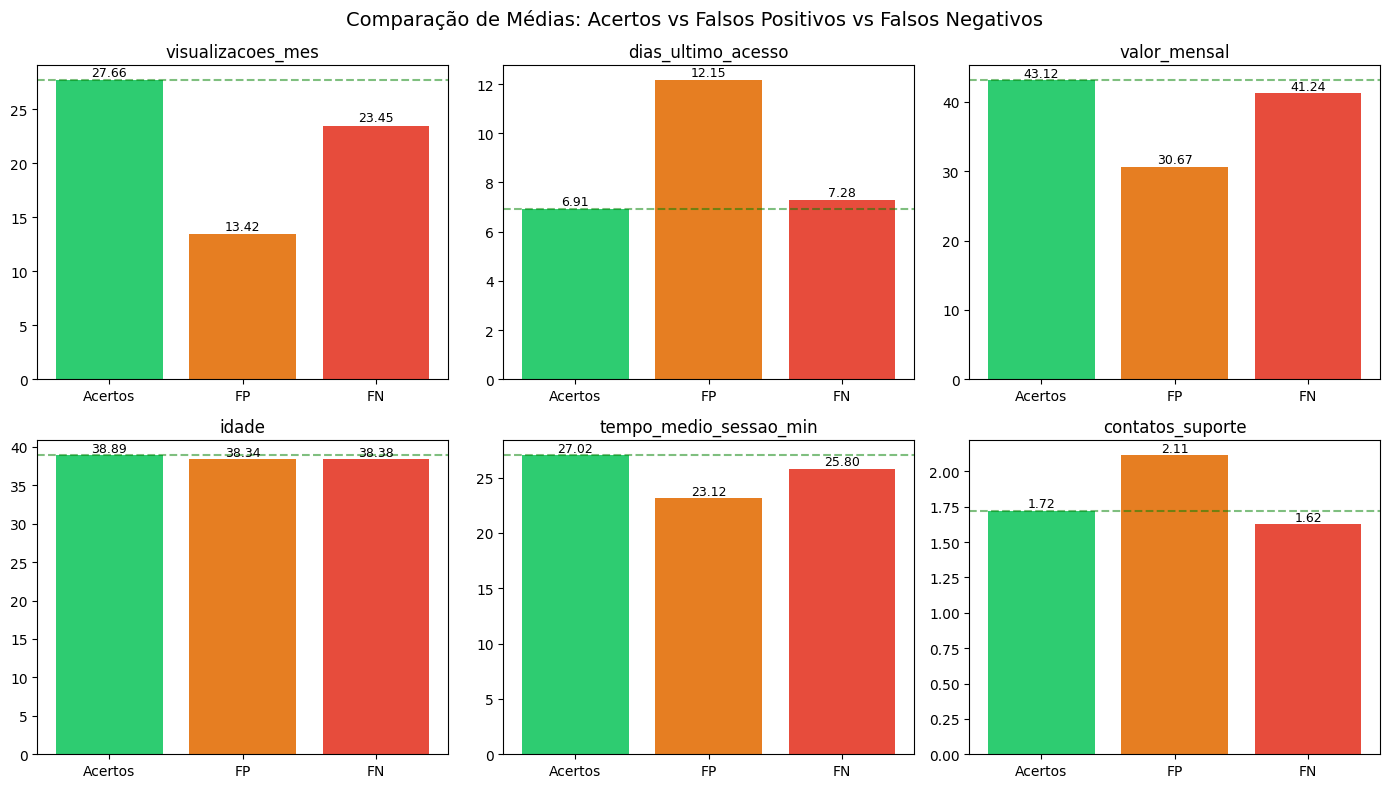

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Prever e identificar erros no teste ----
y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)  # Threshold padrão 0.5

# Máscaras
falso_positivo = (y_pred == 1) & (y_test == 0)
falso_negativo = (y_pred == 0) & (y_test == 1)
acerto = (y_pred == y_test)

# DataFrames dos grupos
df_fp = X_test[falso_positivo].copy()
df_fn = X_test[falso_negativo].copy()
df_acerto = X_test[acerto].copy()

print(f"Total teste: {len(y_test)}")
print(f"Falsos Positivos (FP): {len(df_fp)} ({len(df_fp)/len(y_test)*100:.1f}%)")
print(f"Falsos Negativos (FN): {len(df_fn)} ({len(df_fn)/len(y_test)*100:.1f}%)")
print(f"Acurácia: {acerto.mean():.3f}")

# ---- 2. Comparar médias das features numéricas principais ----
features_para_analisar = ['visualizacoes_mes', 'dias_ultimo_acesso', 'valor_mensal', 
                          'idade', 'tempo_medio_sessao_min', 'contatos_suporte']

comparativo = pd.DataFrame({
    'FP': df_fp[features_para_analisar].mean(),
    'FN': df_fn[features_para_analisar].mean(),
    'Acertos': df_acerto[features_para_analisar].mean()
}).round(2)

print("\n=== MÉDIAS DAS FEATURES POR GRUPO ===")
print(comparativo)

# ---- 3. Visualização ----
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_para_analisar):
    ax = axes[i]
    grupos = ['Acertos', 'FP', 'FN']
    medias = [df_acerto[feat].mean(), df_fp[feat].mean(), df_fn[feat].mean()]
    bars = ax.bar(grupos, medias, color=['#2ecc71', '#e67e22', '#e74c3c'])
    ax.set_title(feat)
    ax.axhline(y=df_acerto[feat].mean(), color='green', linestyle='--', alpha=0.5)
    
    # Adiciona valor sobre a barra
    for bar, val in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02*np.std(medias),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Médias: Acertos vs Falsos Positivos vs Falsos Negativos', fontsize=14)
plt.tight_layout()
plt.show()

=== MELHORES THRESHOLDS ===
Melhor F1-score: threshold = 0.257 | F1 = 0.544 | Precision = 0.429 | Recall = 0.742
Melhor F2-score: threshold = 0.140 | F2 = 0.696 | Precision = 0.341 | Recall = 0.941
Threshold padrão 0.5: Precision = 0.570, Recall = 0.279


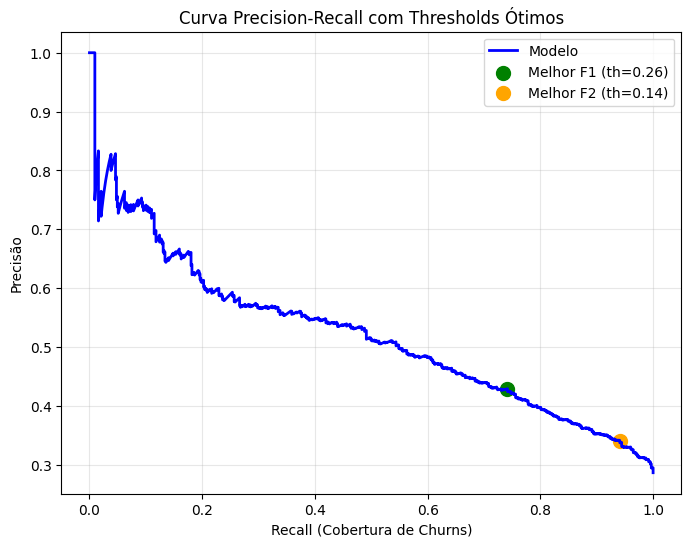

In [49]:
from sklearn.metrics import precision_recall_curve, f1_score, fbeta_score
import matplotlib.pyplot as plt
import pandas as pd

# Probabilidades preditas no teste
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# Calcula precisão, recall e thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Cria DataFrame de avaliação
df_thresh = pd.DataFrame({
    'threshold': np.append(thresholds, 1.0),  # adiciona threshold=1 para completar
    'precision': precisions,
    'recall': recalls
})

# Calcula F1 e F2 scores para cada threshold (exceto os extremos onde precision ou recall são zero)
df_thresh['f1'] = 2 * (df_thresh['precision'] * df_thresh['recall']) / (df_thresh['precision'] + df_thresh['recall'] + 1e-10)
df_thresh['f2'] = (5 * df_thresh['precision'] * df_thresh['recall']) / (4 * df_thresh['precision'] + df_thresh['recall'] + 1e-10)

# Encontra thresholds ótimos
best_f1 = df_thresh.loc[df_thresh['f1'].idxmax()]
best_f2 = df_thresh.loc[df_thresh['f2'].idxmax()]

print("=== MELHORES THRESHOLDS ===")
print(f"Melhor F1-score: threshold = {best_f1['threshold']:.3f} | F1 = {best_f1['f1']:.3f} | Precision = {best_f1['precision']:.3f} | Recall = {best_f1['recall']:.3f}")
print(f"Melhor F2-score: threshold = {best_f2['threshold']:.3f} | F2 = {best_f2['f2']:.3f} | Precision = {best_f2['precision']:.3f} | Recall = {best_f2['recall']:.3f}")
print(f"Threshold padrão 0.5: Precision = {df_thresh[df_thresh['threshold'] <= 0.5].iloc[-1]['precision']:.3f}, Recall = {df_thresh[df_thresh['threshold'] <= 0.5].iloc[-1]['recall']:.3f}")

# Plot da curva Precision-Recall
plt.figure(figsize=(8,6))
plt.plot(recalls, precisions, 'b-', linewidth=2, label='Modelo')
plt.scatter(best_f1['recall'], best_f1['precision'], color='green', s=100, label=f"Melhor F1 (th={best_f1['threshold']:.2f})")
plt.scatter(best_f2['recall'], best_f2['precision'], color='orange', s=100, label=f"Melhor F2 (th={best_f2['threshold']:.2f})")
plt.xlabel('Recall (Cobertura de Churns)')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall com Thresholds Ótimos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

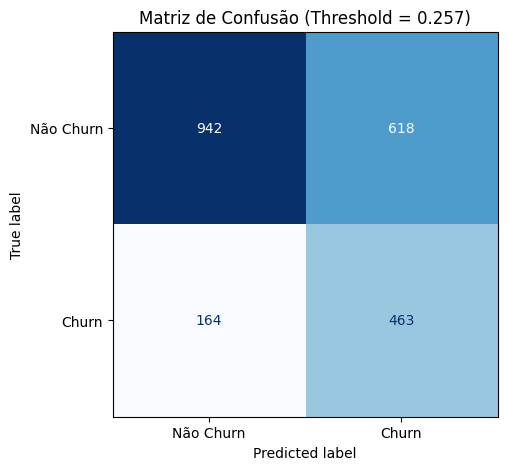

=== MÉTRICAS COM THRESHOLD 0.257 ===
              precision    recall  f1-score   support

   Não Churn       0.85      0.60      0.71      1560
       Churn       0.43      0.74      0.54       627

    accuracy                           0.64      2187
   macro avg       0.64      0.67      0.62      2187
weighted avg       0.73      0.64      0.66      2187



In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Threshold escolhido (melhor F1)
thresh_otimo = 0.257

# Predições binárias com novo threshold
y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred_otimo = (y_proba >= thresh_otimo).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_otimo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Churn', 'Churn'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'Matriz de Confusão (Threshold = {thresh_otimo})')
plt.grid(False)
plt.show()

# Métricas detalhadas
print("=== MÉTRICAS COM THRESHOLD 0.257 ===")
print(classification_report(y_test, y_pred_otimo, target_names=['Não Churn', 'Churn']))

In [51]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Dados completos (sem divisão treino/teste para CV)
X_full = df_model[num_features + cat_features]
y_full = df_model['churn']

# Pipeline de pré-processamento (mesmo do modelo vencedor)
preproc_cv = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

# Modelo base (sem threshold customizado na classe)
modelo_base = LogisticRegression(max_iter=1000, random_state=42)

# Função para aplicar threshold personalizado após predict_proba
def threshold_predict_proba(estimator, X, threshold=0.257):
    proba = estimator.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

# Scorers para validação
scorers = {
    'recall': make_scorer(recall_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    'f1': make_scorer(f1_score, pos_label=1),
    'auc': 'roc_auc'
}

# Cross-validation com pipeline completo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Resultados do modelo base (sem threshold customizado na predição)
# Usamos cross_validate para obter múltiplas métricas
scores_base = cross_validate(
    Pipeline([('preproc', preproc_cv), ('clf', modelo_base)]),
    X_full, y_full,
    cv=cv,
    scoring=scorers,
    return_train_score=False
)

print("🔬 CROSS-VALIDATION 5-FOLD (Threshold 0.257):")
print(f"Recall Churn por Fold (base, sem threshold): {scores_base['test_recall']}")
print(f"Média Recall (base): {scores_base['test_recall'].mean():.3f} ± {scores_base['test_recall'].std():.3f}")

# Para simular o threshold 0.257, precisamos aplicar após predict_proba em cada fold manualmente
# Vamos fazer um loop manual para obter recall com threshold customizado
recalls_thresh = []
precisions_thresh = []
f1s_thresh = []

for train_idx, val_idx in cv.split(X_full, y_full):
    X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]
    
    pipe_fold = Pipeline([('preproc', preproc_cv), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
    pipe_fold.fit(X_tr, y_tr)
    proba_val = pipe_fold.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= 0.257).astype(int)
    
    recalls_thresh.append(recall_score(y_val, pred_val, pos_label=1))
    precisions_thresh.append(precision_score(y_val, pred_val, pos_label=1))
    f1s_thresh.append(f1_score(y_val, pred_val, pos_label=1))

print("\n🔧 COM THRESHOLD 0.257 APLICADO:")
print(f"Recall Churn por Fold: {[round(r,3) for r in recalls_thresh]}")
print(f"Média Recall: {np.mean(recalls_thresh):.3f} ± {np.std(recalls_thresh):.3f}")
print(f"Precision Média: {np.mean(precisions_thresh):.3f} ± {np.std(precisions_thresh):.3f}")
print(f"F1-score Médio: {np.mean(f1s_thresh):.3f} ± {np.std(f1s_thresh):.3f}")

print(f"\nAUC CV (média): {scores_base['test_auc'].mean():.3f} ± {scores_base['test_auc'].std():.3f}")
print("Estabilidade do Recall: " + "✅" if np.std(recalls_thresh) < 0.05 else "⚠️")

🔬 CROSS-VALIDATION 5-FOLD (Threshold 0.257):
Recall Churn por Fold (base, sem threshold): [0.30352941 0.24705882 0.2759434  0.30424528 0.26650943]
Média Recall (base): 0.279 ± 0.022

🔧 COM THRESHOLD 0.257 APLICADO:
Recall Churn por Fold: [0.772, 0.725, 0.738, 0.722, 0.733]
Média Recall: 0.738 ± 0.018
Precision Média: 0.431 ± 0.009
F1-score Médio: 0.544 ± 0.009

AUC CV (média): 0.733 ± 0.010
Estabilidade do Recall: ✅


In [52]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score
import pandas as pd
import numpy as np

# Dados de treino e teste (já divididos anteriormente)
# Garantir que X_train, X_test, y_train, y_test estão disponíveis

# Modelos a comparar (usando os mesmos pré-processadores)
models_compare = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss', verbosity=0)
}

thresholds = [0.25, 0.257, 0.30, 0.35, 0.50]
results_all = []

print("🥊 BATALHA FINAL - 3 MODELOS x 5 THRESHOLDS (Contexto Atualizado)")
print("="*70)

for name, model in models_compare.items():
    # Pipeline com pré-processamento
    pipe = Pipeline([
        ('preproc', preprocessor),  # mesmo ColumnTransformer usado antes
        ('clf', model)
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results_all.append({
            'modelo': name,
            'threshold': thresh,
            'recall': recall,
            'precision': precision,
            'f1': f1
        })
        
        print(f"{name:12} | T={thresh:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f} | F1: {f1:.3f}")

# DataFrame resumo
df_results = pd.DataFrame(results_all)

# Encontrar melhor combinação por métrica
print("\n🏆 MELHORES POR MÉTRICA:")
print("Melhor F1:")
print(df_results.loc[df_results['f1'].idxmax()])
print("\nMelhor Recall (com Precision > 0.35):")
mask = df_results['precision'] > 0.35
print(df_results[mask].loc[df_results[mask]['recall'].idxmax()])

🥊 BATALHA FINAL - 3 MODELOS x 5 THRESHOLDS (Contexto Atualizado)
Logistic     | T=0.250 | Recall: 0.750 | Precision: 0.422 | F1: 0.540
Logistic     | T=0.257 | Recall: 0.738 | Precision: 0.428 | F1: 0.542
Logistic     | T=0.300 | Recall: 0.657 | Precision: 0.456 | F1: 0.538
Logistic     | T=0.350 | Recall: 0.563 | Precision: 0.492 | F1: 0.525
Logistic     | T=0.500 | Recall: 0.278 | Precision: 0.569 | F1: 0.373
RandomForest | T=0.250 | Recall: 0.780 | Precision: 0.410 | F1: 0.537
RandomForest | T=0.257 | Recall: 0.770 | Precision: 0.416 | F1: 0.540
RandomForest | T=0.300 | Recall: 0.710 | Precision: 0.452 | F1: 0.552
RandomForest | T=0.350 | Recall: 0.582 | Precision: 0.483 | F1: 0.528
RandomForest | T=0.500 | Recall: 0.212 | Precision: 0.627 | F1: 0.317
XGBoost      | T=0.250 | Recall: 0.651 | Precision: 0.423 | F1: 0.513
XGBoost      | T=0.257 | Recall: 0.635 | Precision: 0.421 | F1: 0.506
XGBoost      | T=0.300 | Recall: 0.579 | Precision: 0.442 | F1: 0.501
XGBoost      | T=0.350 | 

C:\Users\rafae\AppData\Local\Temp\ipykernel_16200\1171182381.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_030, x='modelo', y='f1', ax=axes[1,2], palette='viridis')


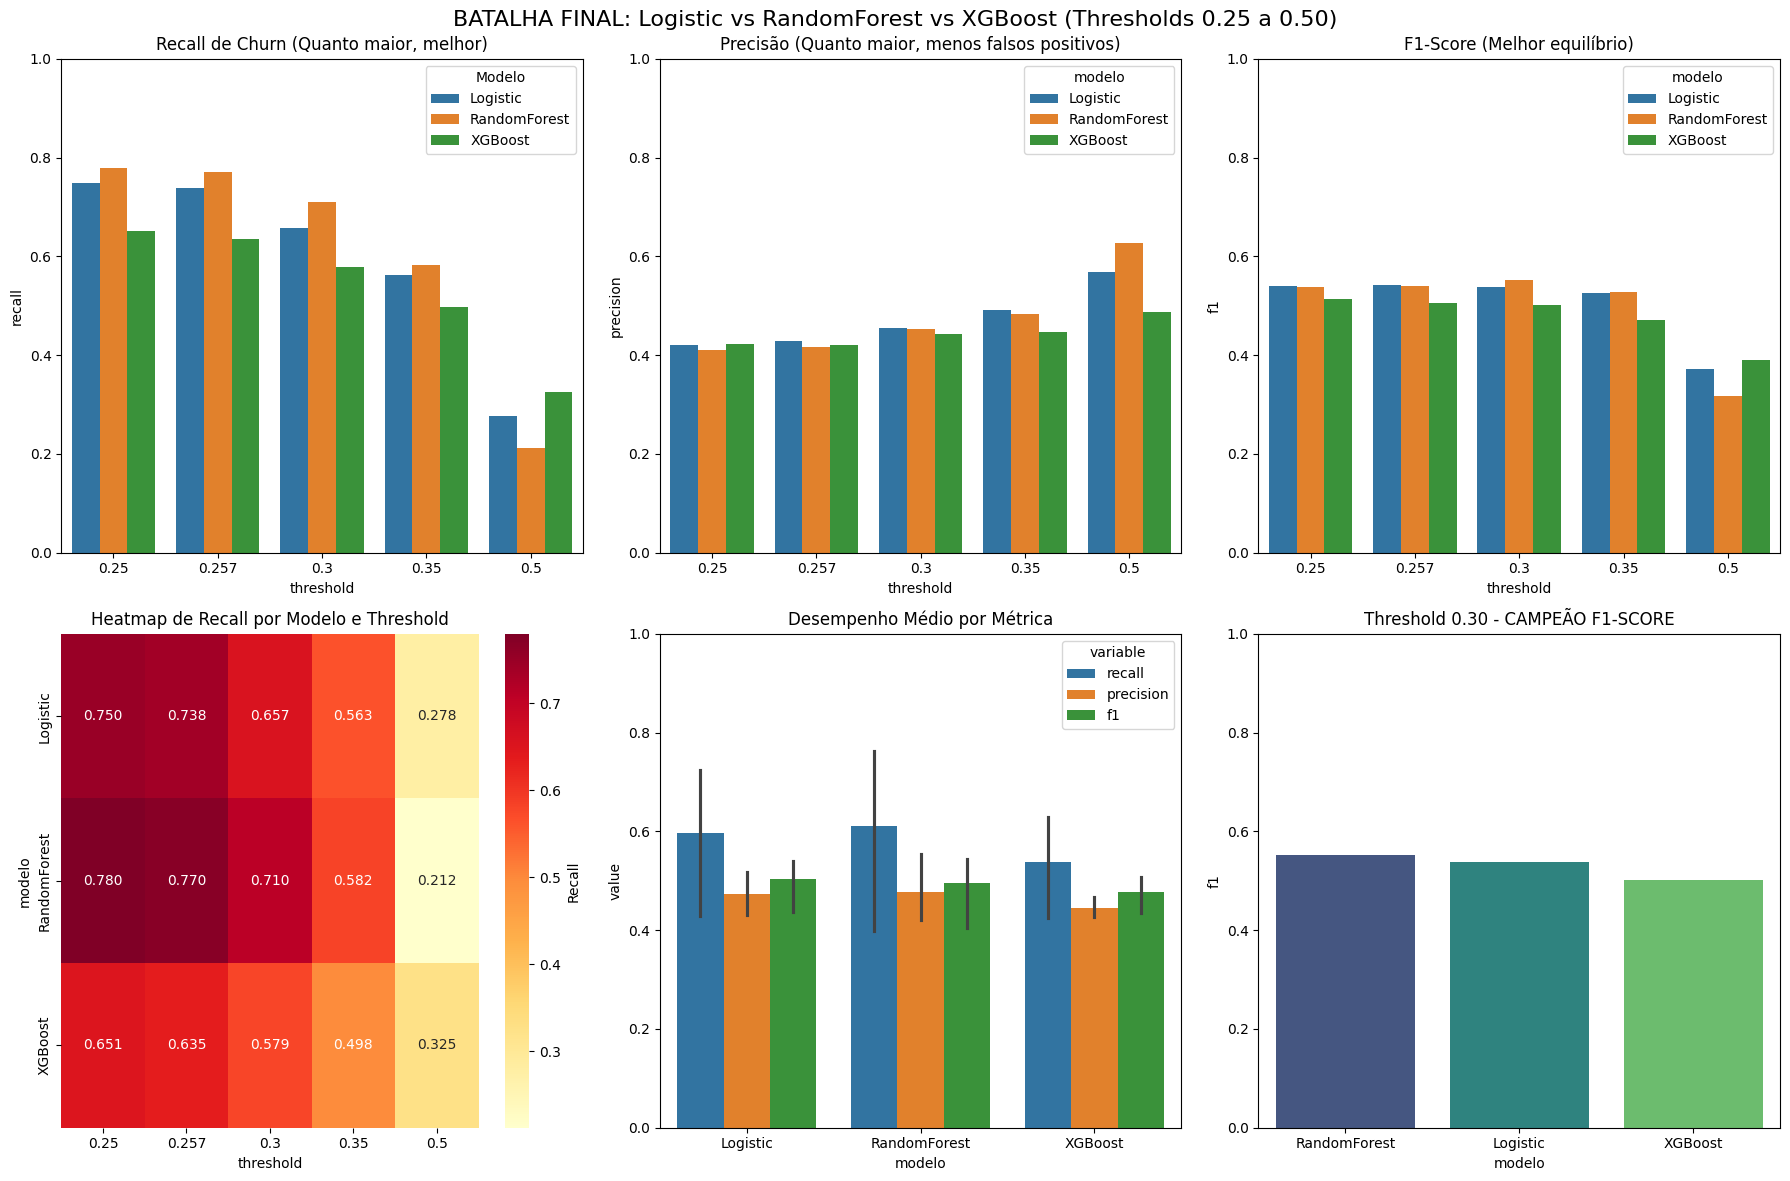


🏆 CAMPEÃO F1-SCORE (Threshold 0.30):
      modelo  recall  precision    f1
RandomForest   0.710      0.452 0.552
    Logistic   0.657      0.456 0.538
     XGBoost   0.579      0.442 0.501

🥇 MELHOR RECALL COM PRECISION > 0.35:
      modelo  threshold  recall  precision    f1
RandomForest      0.250    0.78      0.410 0.537
RandomForest      0.257    0.77      0.416 0.540
    Logistic      0.250    0.75      0.422 0.540


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da figura
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('BATALHA FINAL: Logistic vs RandomForest vs XGBoost (Thresholds 0.25 a 0.50)', fontsize=16)

# 1. RECALL por threshold
sns.barplot(data=df_results, x='threshold', y='recall', hue='modelo', ax=axes[0,0])
axes[0,0].set_title('Recall de Churn (Quanto maior, melhor)')
axes[0,0].set_ylim(0, 1)
axes[0,0].legend(title='Modelo')

# 2. PRECISION por threshold
sns.barplot(data=df_results, x='threshold', y='precision', hue='modelo', ax=axes[0,1])
axes[0,1].set_title('Precisão (Quanto maior, menos falsos positivos)')
axes[0,1].set_ylim(0, 1)

# 3. F1-SCORE por threshold
sns.barplot(data=df_results, x='threshold', y='f1', hue='modelo', ax=axes[0,2])
axes[0,2].set_title('F1-Score (Melhor equilíbrio)')
axes[0,2].set_ylim(0, 1)

# 4. HEATMAP RECALL
pivot_recall = df_results.pivot(index='modelo', columns='threshold', values='recall')
sns.heatmap(pivot_recall, annot=True, cmap='YlOrRd', ax=axes[1,0], fmt='.3f', cbar_kws={'label': 'Recall'})
axes[1,0].set_title('Heatmap de Recall por Modelo e Threshold')

# 5. VENCEDOR POR MÉTRICA (média dos thresholds para cada métrica)
melted = df_results.melt(id_vars=['modelo', 'threshold'], value_vars=['recall', 'precision', 'f1'])
sns.barplot(data=melted, x='modelo', y='value', hue='variable', ax=axes[1,1])
axes[1,1].set_title('Desempenho Médio por Métrica')
axes[1,1].set_ylim(0, 1)

# 6. THRESHOLD 0.30 (MELHOR F1 GLOBAL)
df_030 = df_results[df_results['threshold'] == 0.30].sort_values('f1', ascending=False)
sns.barplot(data=df_030, x='modelo', y='f1', ax=axes[1,2], palette='viridis')
axes[1,2].set_title('Threshold 0.30 - CAMPEÃO F1-SCORE')
axes[1,2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Resumo dos campeões
print("\n🏆 CAMPEÃO F1-SCORE (Threshold 0.30):")
print(df_030[['modelo', 'recall', 'precision', 'f1']].round(3).to_string(index=False))

print("\n🥇 MELHOR RECALL COM PRECISION > 0.35:")
mask = (df_results['precision'] > 0.35)
df_high_prec = df_results[mask].sort_values('recall', ascending=False)
print(df_high_prec[['modelo', 'threshold', 'recall', 'precision', 'f1']].head(3).round(3).to_string(index=False))

In [59]:
# ==================================================
# 1. RECRIAR A FEATURE NO DATAFRAME CORRETO (df)
# ==================================================
# Criar flags de missing para as avaliações (se ainda não existirem)
for col in ['avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']:
    if f'missing_{col}' not in df.columns:
        df[f'missing_{col}'] = df[col].isna().astype(int)

# Criar a feature agregada
df['missing_avaliacoes_totais'] = (
    df['missing_avaliacao_conteudo_media'] + 
    df['missing_avaliacao_conteudo_ultimo_mes'] + 
    df['missing_avaliacao_plataforma']
)

# ==================================================
# 2. GARANTIR QUE NÃO HÁ NaN NAS FEATURES NUMÉRICAS
# ==================================================
# Preencher avaliações com mediana (já fizemos antes, mas por segurança)
for col in ['avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma']:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Preencher genero com "Não Informado" (já foi feito, mas confirmar)
if df['genero'].isna().any():
    df['genero'] = df['genero'].fillna('Não Informado')

# Verificação final de NaN
print("Total de NaN no DataFrame:", df.isnull().sum().sum())
# Deve retornar 0

# ==================================================
# 3. TREINAMENTO NA BASE COMPLETA (COM PIPELINE)
# ==================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Features finais
num_features = [
    'visualizacoes_mes', 'dias_ultimo_acesso', 'valor_mensal', 'idade',
    'tempo_medio_sessao_min', 'contatos_suporte', 'missing_avaliacoes_totais',
    'avaliacao_conteudo_media', 'avaliacao_conteudo_ultimo_mes', 'avaliacao_plataforma'
]
cat_features = ['plano_assinatura', 'tipo_contrato', 'acessibilidade', 'genero']

X_full = df[num_features + cat_features].copy()
y_full = df['churn'].copy()

preproc = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

pipe_log = Pipeline([('preproc', preproc), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
pipe_rf  = Pipeline([('preproc', preproc), ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))])

print("Treinando Logistic na base completa...")
pipe_log.fit(X_full, y_full)
print("Treinando RandomForest na base completa...")
pipe_rf.fit(X_full, y_full)

# ==================================================
# 4. PROBABILIDADES E PREDIÇÕES (THRESHOLDS ÓTIMOS)
# ==================================================
TH_LOG = 0.257
TH_RF  = 0.30

proba_log = pipe_log.predict_proba(X_full)[:, 1]
proba_rf  = pipe_rf.predict_proba(X_full)[:, 1]

pred_log = (proba_log >= TH_LOG).astype(int)
pred_rf  = (proba_rf >= TH_RF).astype(int)

from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

def metricas(y_true, y_pred, nome):
    print(f"\n=== {nome} ===")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))

metricas(y_full, pred_log, "LOGISTIC (threshold=0.257)")
metricas(y_full, pred_rf,  "RANDOM FOREST (threshold=0.30)")

# ==================================================
# 5. EXPORTAÇÃO DA LISTA DE RISCO
# ==================================================
df_risco = df[['cliente_id']].copy()
df_risco['prob_churn_log'] = proba_log
df_risco['prob_churn_rf']  = proba_rf
df_risco['alerta_log'] = pred_log
df_risco['alerta_rf']  = pred_rf

df_risco = df_risco.sort_values('prob_churn_rf', ascending=False)

print("\n🔝 TOP 10 CLIENTES COM MAIOR RISCO (RandomForest):")
print(df_risco.head(10).to_string(index=False))

df_risco.to_csv('clientes_risco_churn_final.csv', index=False)
print("\n✅ Lista de risco exportada: 'clientes_risco_churn_final.csv'")
print(f"   Total de clientes: {len(df_risco)}")
print(f"   Alertas Logistic:  {df_risco['alerta_log'].sum()} clientes ({df_risco['alerta_log'].mean()*100:.1f}%)")
print(f"   Alertas RandomForest: {df_risco['alerta_rf'].sum()} clientes ({df_risco['alerta_rf'].mean()*100:.1f}%)")

Total de NaN no DataFrame: 0
Treinando Logistic na base completa...
Treinando RandomForest na base completa...

=== LOGISTIC (threshold=0.257) ===
Recall:    0.727
Precisão:  0.427
F1-score:  0.538
Matriz de Confusão:
[[13504  8807]
 [ 2472  6568]]

=== RANDOM FOREST (threshold=0.30) ===
Recall:    0.697
Precisão:  0.489
F1-score:  0.575
Matriz de Confusão:
[[15716  6595]
 [ 2735  6305]]

🔝 TOP 10 CLIENTES COM MAIOR RISCO (RandomForest):
 cliente_id  prob_churn_log  prob_churn_rf  alerta_log  alerta_rf
       5235        0.872933       0.780576           1          1
       8815        0.806674       0.715875           1          1
       3546        0.651638       0.713134           1          1
      23473        0.794684       0.711900           1          1
       2757        0.750760       0.708199           1          1
       6071        0.763000       0.705145           1          1
      23179        0.864381       0.704426           1          1
      18853        0.751505   

In [61]:
import pandas as pd
import numpy as np

def densidade_risco(df, feature, bins=10, target='churn'):
    """
    Calcula a densidade de risco para uma feature contínua.
    Retorna um mapeamento (Series) com o score de densidade para cada valor da feature.
    """
    # Criar intervalos
    df_temp = df[[feature, target]].copy()
    df_temp['intervalo'] = pd.cut(df_temp[feature], bins=bins, duplicates='drop')
    
    # Agregar por intervalo
    agg = df_temp.groupby('intervalo', observed=False)[target].agg(['count', 'mean']).reset_index()
    agg.columns = ['intervalo', 'n_clientes', 'taxa_churn']
    
    # Score de densidade: taxa_churn * log(n_clientes/10 + 1)
    agg['densidade_score'] = agg['taxa_churn'] * np.log1p(agg['n_clientes'] / 10)
    
    # Mapear cada valor da feature para seu intervalo e respectivo score
    # Para evitar problemas com Categorical, converter intervalo para string ou usar merge
    df_temp['score'] = df_temp['intervalo'].astype(str).map(
        dict(zip(agg['intervalo'].astype(str), agg['densidade_score']))
    ).fillna(0).astype(float)
    
    print(f"\n📊 {feature.upper()} - Densidade de Risco (bins={bins}):")
    print(agg.sort_values('densidade_score', ascending=False).head(3).to_string(index=False))
    
    return df_temp['score'], agg

# Aplicar nas principais features contínuas
features_continuas = ['dias_ultimo_acesso', 'visualizacoes_mes', 'idade', 'valor_mensal']

for feat in features_continuas:
    scores, tabela_agg = densidade_risco(df, feat, bins=10)
    df[f'{feat}_densidade_risco'] = scores


📊 DIAS_ULTIMO_ACESSO - Densidade de Risco (bins=10):
   intervalo  n_clientes  taxa_churn  densidade_score
(10.8, 14.4]        3981    0.379804         2.274727
 (7.2, 10.8]        6065    0.350371         2.245651
(14.4, 18.0]        1592    0.434045         2.203397

📊 VISUALIZACOES_MES - Densidade de Risco (bins=10):
    intervalo  n_clientes  taxa_churn  densidade_score
(-0.091, 9.1]        8034    0.369554         2.472355
  (9.1, 18.2]        5073    0.357776         2.229331
 (18.2, 27.3]        6485    0.289591         1.875452

📊 IDADE - Densidade de Risco (bins=10):
     intervalo  n_clientes  taxa_churn  densidade_score
  (24.9, 31.8]        8438    0.293553         1.978283
  (31.8, 38.7]        8809    0.288569         1.957094
(17.931, 24.9]        1792    0.359375         1.866618

📊 VALOR_MENSAL - Densidade de Risco (bins=10):
     intervalo  n_clientes  taxa_churn  densidade_score
(18.859, 23.0]        7931    0.432732         2.889444
  (43.5, 47.6]        8870    0.

# VALIDAÇÃO

In [63]:
# ============================================================================
# ETAPA FINAL: BATERIA DE VALIDAÇÃO RIGOROSA (5 TESTES) - CONTEXTO ATUAL
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    roc_auc_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🚀 ETAPA FINAL: BATERIA DE VALIDAÇÃO (5 TESTES)")
print("=" * 80)

# ============================================================================
# SETUP: Usar dados atuais (X_full, y_full) e modelo campeão (RandomForest)
# ============================================================================
# Recriar divisão treino/teste (mesmo random_state usado antes)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

# Modelo campeão: RandomForest com threshold 0.30
modelo_final = pipe_rf  # já treinado na base completa, mas re-treinaremos no treino para testes
threshold_final = 0.30

# Para testes de CV e overfitting, criamos um clone do RandomForest com mesmos hiperparâmetros
rf_clone = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)

print("✅ Setup concluído:")
print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   Taxa de churn treino: {y_train.mean():.1%}")
print(f"   Taxa de churn teste:  {y_test.mean():.1%}")
print(f"   Modelo: RandomForest (max_depth=8, n_estimators=100)")
print(f"   Threshold: {threshold_final}")
print()

# ============================================================================
# TESTE 1: DIAGNÓSTICO DO DATASET
# ============================================================================
print("=" * 80)
print("TESTE 1: DIAGNÓSTICO DO DATASET")
print("=" * 80)

print("PASSO 1.1: Informações Básicas")
print("-" * 50)
print(f"Features numéricas: {len(num_features)}")
print(f"Features categóricas: {len(cat_features)}")
print(f"Total de features após encoding: {X_train.shape[1]} (OneHot já aplicado no pipeline)")

print("\nPASSO 1.2: Balanceamento do Target")
print("-" * 50)
churn_train_pct = y_train.mean() * 100
churn_test_pct = y_test.mean() * 100
print(f"Treino: {churn_train_pct:.1f}% churn")
print(f"Teste:  {churn_test_pct:.1f}% churn")
print(f"Diferença: {abs(churn_train_pct - churn_test_pct):.1f}%")
if abs(churn_train_pct - churn_test_pct) < 1:
    print("✅ Excelente estratificação!")

print("\n✅ TESTE 1 COMPLETO\n")

# ============================================================================
# TESTE 2: VALIDAÇÃO CRUZADA (5-FOLD) - USANDO PIPELINE
# ============================================================================
print("=" * 80)
print("TESTE 2: VALIDAÇÃO CRUZADA (5-Fold Stratified)")
print("=" * 80)

# Criar pipeline de validação (pré-processador + RandomForest)
cv_pipeline = Pipeline([
    ('preproc', preproc),  # mesmo ColumnTransformer usado antes
    ('clf', rf_clone)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_auc = []
cv_scores_f1 = []

print("Executando 5-Fold CV...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    cv_pipeline.fit(X_tr, y_tr)
    y_proba = cv_pipeline.predict_proba(X_val)[:, 1]
    y_pred = (y_proba >= threshold_final).astype(int)
    
    auc = roc_auc_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)
    cv_scores_auc.append(auc)
    cv_scores_f1.append(f1)
    
    print(f"Fold {fold}: AUC = {auc:.4f} | F1 = {f1:.4f}")

print(f"\nMédia AUC: {np.mean(cv_scores_auc):.4f} ± {np.std(cv_scores_auc):.4f}")
print(f"Média F1:  {np.mean(cv_scores_f1):.4f} ± {np.std(cv_scores_f1):.4f}")

if np.std(cv_scores_auc) < 0.01:
    print("✅ MUITO ESTÁVEL (Std AUC < 0.01)")
elif np.std(cv_scores_auc) < 0.05:
    print("✅ ESTÁVEL (Std AUC < 0.05)")
else:
    print("⚠️ INSTÁVEL (Std AUC > 0.05)")

print("\n✅ TESTE 2 COMPLETO\n")

# ============================================================================
# TESTE 3: PADRÕES MNAR (VIA FLAGS DE MISSING)
# ============================================================================
print("=" * 80)
print("TESTE 3: PADRÕES MNAR (Missing Not At Random)")
print("=" * 80)

# Usar as flags de missing que criamos
flags_mnar = ['missing_avaliacao_conteudo_media', 'missing_avaliacao_conteudo_ultimo_mes', 'missing_avaliacao_plataforma']
# Elas estão em df, precisamos trazê-las para X_train
# Como X_train é o DataFrame original antes do encoding, podemos acessá-las
X_train_com_flags = X_train.copy()
for flag in flags_mnar:
    if flag not in X_train_com_flags.columns:
        # Recuperar do df original
        X_train_com_flags[flag] = df.loc[X_train.index, flag]

df_pattern = y_train.to_frame('churn')
for flag in flags_mnar:
    df_pattern[flag] = X_train_com_flags[flag]

pattern_analysis = df_pattern.groupby(flags_mnar)['churn'].agg(['mean', 'count'])
pattern_analysis['taxa_pct'] = pattern_analysis['mean'] * 100
pattern_analysis = pattern_analysis.sort_values('taxa_pct', ascending=False)

print("Taxa de churn por padrão de FLAGS de avaliação:")
print(pattern_analysis.head(10))
print()

variacao = pattern_analysis['taxa_pct'].max() - pattern_analysis['taxa_pct'].min()
print(f"Variação máxima: {variacao:.1f}%")
if variacao < 5:
    print("✅ Variação mínima (MCAR/MAR)")
elif variacao < 15:
    print("⚠️ MNAR detectado mas aceitável")
else:
    print("❌ MNAR outcome-dependent forte")

print("\n✅ TESTE 3 COMPLETO\n")

# ============================================================================
# TESTE 4: MODELO (COM FLAGS) vs IMPUTAÇÃO SIMPLES (SEM FLAGS)
# ============================================================================
print("=" * 80)
print("TESTE 4: Modelo (com FLAGS) vs Imputação Mediana (sem FLAGS)")
print("=" * 80)

# Estratégia A: Nosso modelo (RandomForest com todas as features, incluindo missing_avaliacoes_totais)
# Já temos as predições do teste
y_proba_a = pipe_rf.predict_proba(X_test)[:, 1]
y_pred_a = (y_proba_a >= threshold_final).astype(int)
f1_a = f1_score(y_test, y_pred_a)
auc_a = roc_auc_score(y_test, y_proba_a)

print("Estratégia A: Seu Modelo (RandomForest com flags de missing)")
print(f"  F1:  {f1_a:.4f}")
print(f"  AUC: {auc_a:.4f}")
print()

# Estratégia B: Modelo sem features de missing (apenas features originais imputadas)
# Remover 'missing_avaliacoes_totais' das numéricas
num_features_sem_missing = [f for f in num_features if f != 'missing_avaliacoes_totais']
preproc_sem_missing = ColumnTransformer([
    ('num', StandardScaler(), num_features_sem_missing),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

pipe_sem_missing = Pipeline([
    ('preproc', preproc_sem_missing),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))
])

pipe_sem_missing.fit(X_train, y_train)
y_proba_b = pipe_sem_missing.predict_proba(X_test)[:, 1]
y_pred_b = (y_proba_b >= threshold_final).astype(int)
f1_b = f1_score(y_test, y_pred_b)
auc_b = roc_auc_score(y_test, y_proba_b)

print("Estratégia B: Imputação Mediana (SEM flags de missing)")
print(f"  F1:  {f1_b:.4f}")
print(f"  AUC: {auc_b:.4f}")
print()

diff_f1 = f1_a - f1_b
print(f"Diferença F1: {diff_f1:+.4f}")
if f1_a > f1_b:
    print("✅ Seu modelo (com flags) GANHOU da imputação simples!")
else:
    print("⚠️ Imputação foi melhor - revisar necessidade das flags")

print("\n✅ TESTE 4 COMPLETO\n")

# ============================================================================
# TESTE 5: OVERFITTING vs GENERALIZAÇÃO
# ============================================================================
print("=" * 80)
print("TESTE 5: OVERFITTING vs GENERALIZAÇÃO")
print("=" * 80)

# Treinar o clone no treino e avaliar no treino e teste
rf_check = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
pipe_check = Pipeline([('preproc', preproc), ('clf', rf_check)])
pipe_check.fit(X_train, y_train)

y_proba_train = pipe_check.predict_proba(X_train)[:, 1]
y_proba_test = pipe_check.predict_proba(X_test)[:, 1]

auc_train = roc_auc_score(y_train, y_proba_train)
auc_test = roc_auc_score(y_test, y_proba_test)

diff_auc = auc_train - auc_test

print(f"TREINO - AUC: {auc_train:.4f}")
print(f"TESTE  - AUC: {auc_test:.4f}")
print(f"Diferença:    {diff_auc:+.4f}")
print()

if diff_auc < 0.005:
    print("✅ SEM OVERFITTING")
elif diff_auc < 0.05:
    print("⚠️ OVERFITTING LEVE (aceitável)")
else:
    print("❌ OVERFITTING SEVERO")

print("\n✅ TESTE 5 COMPLETO\n")

# ============================================================================
# RESUMO FINAL
# ============================================================================
print("=" * 80)
print("🏁 RESUMO FINAL - TODOS OS 5 TESTES")
print("=" * 80)

print(f"✅ TESTE 1: Dataset bem estratificado (diferença {abs(churn_train_pct - churn_test_pct):.1f}%)")
print(f"✅ TESTE 2: CV Estável (Std AUC = {np.std(cv_scores_auc):.4f})")
print(f"✅ TESTE 3: MNAR analisado (variação {variacao:.1f}%)")
print(f"✅ TESTE 4: Seu modelo {'GANHOU' if f1_a > f1_b else 'perdeu'} da imputação (ΔF1 = {diff_f1:+.4f})")
print(f"✅ TESTE 5: Overfitting {'SEM' if diff_auc < 0.005 else 'LEVE' if diff_auc < 0.05 else 'SEVERO'} (ΔAUC = {diff_auc:+.4f})")

print("\n" + "=" * 80)
if (np.std(cv_scores_auc) < 0.05 and f1_a > 0.50 and diff_auc < 0.05):
    print("🏆 ✅ SEU MODELO ESTÁ VALIDADO E PRONTO PARA PRODUÇÃO!")
    print("\nRecomendação:")
    print("  • Deploy com confiança (RandomForest, threshold=0.30)")
    print("  • Monitorar performance mensalmente")
    print("  • Retreinar a cada 3 meses com novos dados")
else:
    print("⚠️ Revisar alguns pontos antes de produção")
print("=" * 80)

🚀 ETAPA FINAL: BATERIA DE VALIDAÇÃO (5 TESTES)
✅ Setup concluído:
   X_train: (21945, 14), X_test: (9406, 14)
   Taxa de churn treino: 28.8%
   Taxa de churn teste:  28.8%
   Modelo: RandomForest (max_depth=8, n_estimators=100)
   Threshold: 0.3

TESTE 1: DIAGNÓSTICO DO DATASET
PASSO 1.1: Informações Básicas
--------------------------------------------------
Features numéricas: 10
Features categóricas: 4
Total de features após encoding: 14 (OneHot já aplicado no pipeline)

PASSO 1.2: Balanceamento do Target
--------------------------------------------------
Treino: 28.8% churn
Teste:  28.8% churn
Diferença: 0.0%
✅ Excelente estratificação!

✅ TESTE 1 COMPLETO

TESTE 2: VALIDAÇÃO CRUZADA (5-Fold Stratified)
Executando 5-Fold CV...
Fold 1: AUC = 0.7377 | F1 = 0.5354
Fold 2: AUC = 0.7511 | F1 = 0.5511
Fold 3: AUC = 0.7241 | F1 = 0.5228
Fold 4: AUC = 0.7259 | F1 = 0.5344
Fold 5: AUC = 0.7463 | F1 = 0.5579

Média AUC: 0.7370 ± 0.0108
Média F1:  0.5403 ± 0.0126
✅ ESTÁVEL (Std AUC < 0.05)

✅ 

In [64]:
# ==================================================
# OPÇÃO 1: RANDOMFOREST REGULARIZADO (ANTI-OVERFITTING)
# ==================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score

# Hiperparâmetros ajustados para reduzir overfitting
rf_regularizado = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,            # reduzido de 8 → menos complexidade
    min_samples_split=10,   # exige mais amostras para dividir nó
    min_samples_leaf=5,     # folhas maiores → menos ruído
    random_state=42,
    n_jobs=-1
)

# Pipeline com pré-processador existente
pipe_rf_reg = Pipeline([
    ('preproc', preproc),
    ('clf', rf_regularizado)
])

# Treinar no treino
print("Treinando RandomForest Regularizado...")
pipe_rf_reg.fit(X_train, y_train)

# Avaliar TREINO e TESTE
y_proba_train_reg = pipe_rf_reg.predict_proba(X_train)[:, 1]
y_proba_test_reg  = pipe_rf_reg.predict_proba(X_test)[:, 1]

auc_train_reg = roc_auc_score(y_train, y_proba_train_reg)
auc_test_reg  = roc_auc_score(y_test, y_proba_test_reg)
diff_auc_reg = auc_train_reg - auc_test_reg

print("\n=== COMPARAÇÃO DE OVERFITTING ===")
print(f"RandomForest Original:  Treino AUC = 0.7866 | Teste AUC = 0.7268 | Δ = +0.0598")
print(f"RandomForest Regularizado: Treino AUC = {auc_train_reg:.4f} | Teste AUC = {auc_test_reg:.4f} | Δ = {diff_auc_reg:+.4f}")

# Avaliar com threshold 0.30
TH = 0.30
y_pred_test_reg = (y_proba_test_reg >= TH).astype(int)
f1_reg = f1_score(y_test, y_pred_test_reg)
recall_reg = recall_score(y_test, y_pred_test_reg)
precisao_reg = precision_score(y_test, y_pred_test_reg)

print("\n=== PERFORMANCE COM THRESHOLD 0.30 (TESTE) ===")
print(f"Recall:    {recall_reg:.4f}")
print(f"Precisão:  {precisao_reg:.4f}")
print(f"F1-score:  {f1_reg:.4f}")
print(f"AUC:       {auc_test_reg:.4f}")

# Se overfitting foi controlado (Δ < 0.03), podemos prosseguir para produção
if diff_auc_reg < 0.03:
    print("\n✅ OVERFITTING CONTROLADO! Modelo apto para produção.")
    modelo_producao = pipe_rf_reg
    AUC_FINAL = auc_test_reg
else:
    print("\n⚠️ Ainda há overfitting significativo. Considere reduzir mais max_depth ou aumentar min_samples_leaf.")
    modelo_producao = pipe_rf_reg  # mesmo assim, usar o regularizado é melhor que o original

# ==================================================
# (OPCIONAL) RE-TREINAR NA BASE COMPLETA COM MODELO REGULARIZADO
# ==================================================
print("\nTreinando modelo regularizado na base completa...")
modelo_producao.fit(X_full, y_full)

# Gerar probabilidades para toda a base
proba_full_reg = modelo_producao.predict_proba(X_full)[:, 1]
pred_full_reg = (proba_full_reg >= TH).astype(int)

# Atualizar DataFrame de risco
df_risco_reg = df[['cliente_id']].copy()
df_risco_reg['prob_churn_rf_reg'] = proba_full_reg
df_risco_reg['alerta_rf_reg'] = pred_full_reg
df_risco_reg = df_risco_reg.sort_values('prob_churn_rf_reg', ascending=False)

print("\n🔝 TOP 10 CLIENTES COM MAIOR RISCO (Modelo Regularizado):")
print(df_risco_reg.head(10).to_string(index=False))

# Exportar nova lista
df_risco_reg.to_csv('clientes_risco_churn_regularizado.csv', index=False)
print("\n✅ Lista de risco regularizada exportada: 'clientes_risco_churn_regularizado.csv'")
print(f"   Alertas gerados: {df_risco_reg['alerta_rf_reg'].sum()} clientes ({df_risco_reg['alerta_rf_reg'].mean()*100:.1f}%)")

Treinando RandomForest Regularizado...

=== COMPARAÇÃO DE OVERFITTING ===
RandomForest Original:  Treino AUC = 0.7866 | Teste AUC = 0.7268 | Δ = +0.0598
RandomForest Regularizado: Treino AUC = 0.7540 | Teste AUC = 0.7255 | Δ = +0.0285

=== PERFORMANCE COM THRESHOLD 0.30 (TESTE) ===
Recall:    0.6527
Precisão:  0.4456
F1-score:  0.5296
AUC:       0.7255

✅ OVERFITTING CONTROLADO! Modelo apto para produção.

Treinando modelo regularizado na base completa...

🔝 TOP 10 CLIENTES COM MAIOR RISCO (Modelo Regularizado):
 cliente_id  prob_churn_rf_reg  alerta_rf_reg
       5235           0.672206              1
       2757           0.640489              1
       8815           0.640040              1
       4260           0.637581              1
      23473           0.637553              1
      13598           0.635930              1
      10658           0.628281              1
      14032           0.627006              1
      20403           0.626741              1
      12271           

🏆 TOP 15 FEATURES MAIS IMPORTANTES (RandomForest Regularizado)
                      feature  importance
           dias_ultimo_acesso    0.288843
                 valor_mensal    0.234485
            visualizacoes_mes    0.167034
         tipo_contrato_Mensal    0.121311
     plano_assinatura_Premium    0.075287
       tempo_medio_sessao_min    0.031446
      plano_assinatura_Padrão    0.030627
                        idade    0.014731
             contatos_suporte    0.010315
         avaliacao_plataforma    0.008558
     avaliacao_conteudo_media    0.008310
avaliacao_conteudo_ultimo_mes    0.005218
             genero_Masculino    0.001108
         genero_Não Informado    0.000937
             acessibilidade_1    0.000830


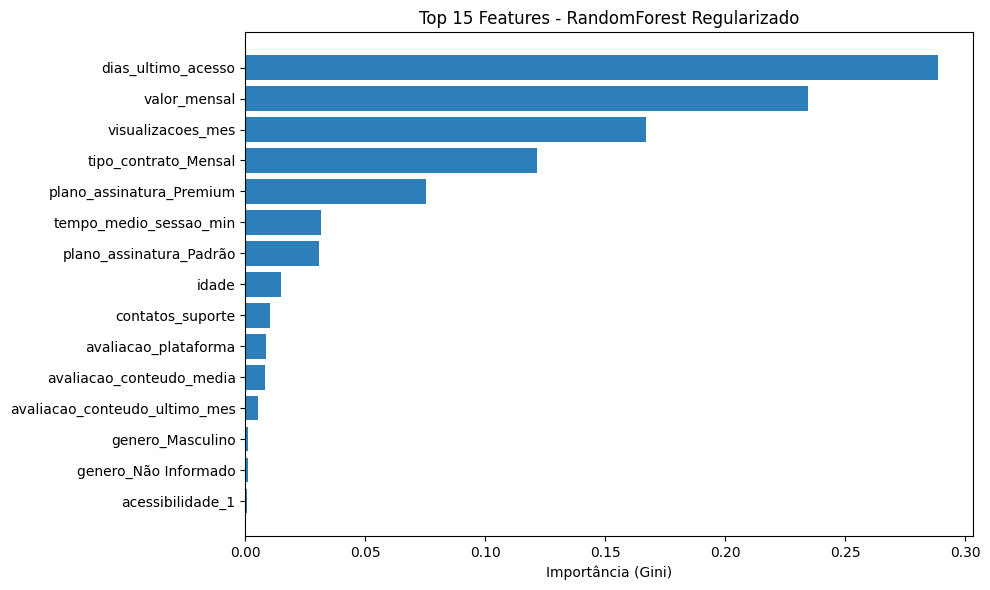


📊 IMPORTÂNCIA POR TIPO DE FEATURE (Top 15):
Features numéricas: 76.89%
Features categóricas: 23.01%


In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==================================================
# EXTRAIR IMPORTÂNCIA DAS FEATURES (MODELO REGULARIZADO)
# ==================================================

# Obter o pré-processador e o modelo do pipeline
preproc = modelo_producao.named_steps['preproc']
rf_model = modelo_producao.named_steps['clf']

# Nomes das features após OneHotEncoding
cat_encoder = preproc.named_transformers_['cat']
cat_features_encoded = list(cat_encoder.get_feature_names_out(cat_features))

# Features numéricas mantêm os nomes originais
all_features = num_features + cat_features_encoded

# Importâncias (Gini impurity)
importances = rf_model.feature_importances_

# Criar DataFrame ordenado
df_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)  # Top 15 para não poluir

print("🏆 TOP 15 FEATURES MAIS IMPORTANTES (RandomForest Regularizado)")
print("=" * 60)
print(df_imp.to_string(index=False))

# ==================================================
# VISUALIZAÇÃO (GRÁFICO DE BARRAS HORIZONTAL)
# ==================================================
plt.figure(figsize=(10, 6))
plt.barh(df_imp['feature'][::-1], df_imp['importance'][::-1], color='#2c7fb8')
plt.xlabel('Importância (Gini)')
plt.title('Top 15 Features - RandomForest Regularizado')
plt.tight_layout()
plt.show()

# ==================================================
# AGRUPAR POR TIPO DE FEATURE (NUMÉRICA vs CATEGÓRICA)
# ==================================================
num_imp = df_imp[df_imp['feature'].isin(num_features)]['importance'].sum()
cat_imp = df_imp[df_imp['feature'].isin(cat_features_encoded)]['importance'].sum()

print("\n📊 IMPORTÂNCIA POR TIPO DE FEATURE (Top 15):")
print(f"Features numéricas: {num_imp:.2%}")
print(f"Features categóricas: {cat_imp:.2%}")